Our objective of predicting PM2.5 concentrations for multiple days ahead requires a model that can capture dependencies at more than one timescale. At a roadside site such as Marylebone, local traffic emissions set a relatively stable baseline that follows predictable weekday and seasonal rhythms, while meteorological conditions drive most of the day-to-day departures from that baseline: wind disperses, rainfall scavenges, and stable conditions allow particulates to accumulate. A hybrid CNN-LSTM is well suited to this structure because it separates the problem into two stages. The 1D convolutional layers slide short filters along the input sequence and extract local patterns spanning a few days, acting as a learned feature extractor that supplies the recurrent stage with a more informative representation than the raw 40 predictors. The LSTM then processes these extracted features in order, using its gated memory to model how they evolve across the input window and to retain the information that remains relevant to the forecast.

Given the size of our dataset, we expect overfitting to be the main constraint on this architecture and we do not anticipate that it will outperform simpler models. The concern is not only that combining convolutional and recurrent components produces a comparatively large number of parameters, but that the amount of independent information available to fit them is smaller than the row count suggests. Because sequences are generated with a sliding window, consecutive training examples share 29 of their 30 days, so the effective sample size is substantially below the number of windows constructed. The training period also spans fewer than four complete annual cycles, which limits how well any seasonal relationship can be estimated, and unlike convolutional networks in computer vision our filters have no pretrained initialisation and must be learned entirely from this data. Simpler models with stronger inductive biases and fewer free parameters are correspondingly less prone to overfitting and may generalise better at this scale.

The 30 day rolling window was selected after experimentation with shorter windows (7, 14, 21 days) which produced mean-collapsing behaviour in the model. Longer window sizes are limited by the number of samples in our test set, which is 364 days. If we were to use a longer window sizes, the number of samples in the test set would be reduced, as more would be required to construct the input sequence, making it hard to evaluate the model's performance honestly. A 30 day window was therefore chosen as a compromise between supplying the convolutional stage with sufficient temporal context and preserving a test set large enough to support an honest evaluation.

## Imports & setup


In [28]:
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

DATA_DIR = "../../data/modelling"
TARGET = "pm25"
DROP_COLS = ["date", TARGET]
MODEL_DIR = Path("saved_cnn_lstm")
MODEL_DIR.mkdir(exist_ok=True)
RESULTS_DIR = Path("cnn_lstm_results")
RESULTS_DIR.mkdir(exist_ok=True)

FORECAST_HORIZONS = [7, 14, 30]  # predict PM2.5 this many days ahead

NUM_EPOCHS = 200
TUNE_EPOCHS = 50  # fewer epochs during grid search
EARLY_STOP_PATIENCE = 20  # final fit: stop if validation MSE does not improve
FINAL_VAL_FRACTION = 0.2  # last fraction of train sequences for final-fit early stopping
CV_SPLITS = 5  # time-series cross-validation folds

# Default architecture — Li et al.
CONV_CHANNELS = (64, 64)  # Conv1d filters (layer1, layer2)
KERNEL_SIZE = 2  # Li et al.: Conv1d filter size 2
POOL_SIZE = 2
DROPOUT = 0.5  # before LSTM (Li et al.), updated to combat overfitting on small dataset

PARAM_GRID = {
    "learning_rate": [0.001, 0.01], # adam default is 0.001 and 0.01 is common for small models like our CNN-LSTM, so these are the two values to try
    "hidden_size": [16, 32, 64, 128, 256], # size of the LSTM hidden state (size of the output from the LSTM for each timestep). Larger hidden_size = more capacity, but also more prone to overfitting on small datasets
    "num_layers": [1, 2],
    "weight_decay": [0.0, 1e-4, 1e-3, 1e-2], # small dataset, so we want to try some regularization
    # reduced channels for small dataset
    "conv_channels": [(128, 128), (64, 64), (32, 32), (16, 16)], # channels are the number of filters in the Conv1d layers, (amount of different filters that slide over the input sequence). Larger channels = more capacity, but also more prone to overfitting on small datasets
}


## Load train & test data


In [29]:
train_df = pd.read_csv(f"{DATA_DIR}/marylebone_train.csv", parse_dates=["date"])
test_df = pd.read_csv(f"{DATA_DIR}/marylebone_test.csv", parse_dates=["date"])

print("Train:", train_df.shape)
print("Test:", test_df.shape)
train_df.head()

Train: (1000, 42)
Test: (364, 42)


,date,year,month,day_of_month,day_of_week_x,day_of_year,week_of_year,quarter,is_weekend,is_weekday,...,air_pressure_max_hpa,air_pressure_min_hpa,temperature_max_c,temperature_min_c,temperature_avg_c,mean_wind_speed_knots,wind_speed_max_knots,wind_speed_min_knots,wind_direction_deg,pm25
0,2022-04-07,2022,4,7,3,97,14,2,0,1,...,1000.9,983.9,13.59414,6.81972,10.206930,13.000000,16.0,4.0,270.636089,5.53
1,2022-04-08,2022,4,8,4,98,14,2,0,1,...,1008.6,997.8,11.35049,1.85771,6.604100,4.291667,9.0,1.0,16.779591,6.72
2,2022-04-09,2022,4,9,5,99,14,2,1,0,...,1019.1,1009.7,12.38106,0.59361,6.487335,5.458333,9.0,3.0,306.186614,5.62
3,2022-04-10,2022,4,10,6,100,14,2,1,0,...,1020.3,1016.2,13.33323,-0.20325,6.564990,2.916667,5.0,1.0,160.738319,8.36
4,2022-04-11,2022,4,11,0,101,15,2,0,1,...,1015.9,1005.9,17.46319,5.01811,11.240650,3.500000,7.0,1.0,119.167789,15.90


## Split features & target


In [30]:
X_train = train_df.drop(columns=DROP_COLS)
y_train = train_df[TARGET]

X_test = test_df.drop(columns=DROP_COLS)
y_test = test_df[TARGET]

feature_cols = X_train.columns.tolist()
print("Features:", len(feature_cols), "| train", X_train.shape, "| test", X_test.shape)


Features: 40 | train (1000, 40) | test (364, 40)


## Scale features & target


In [31]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),  # fit on train only (no leakage)
    columns=feature_cols,
    index=X_train.index,
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index,
)

y_scaler = StandardScaler()
y_train_scaled = pd.Series(
    y_scaler.fit_transform(y_train.to_numpy().reshape(-1, 1)).ravel(), # reshape to 2D for scaler, then back to 1D (ravel) for Series
    index=y_train.index,
    name=TARGET,
)
y_test_scaled = pd.Series(
    y_scaler.transform(y_test.to_numpy().reshape(-1, 1)).ravel(),
    index=y_test.index,
    name=TARGET,
)

print(
    f"y_train mean={y_scaler.mean_[0]:.3f}, std={y_scaler.scale_[0]:.3f} "
    f"(scaled train mean≈{y_train_scaled.mean():.3f}, std≈{y_train_scaled.std():.3f})"
)
X_train_scaled.describe().round(3)


y_train mean=8.490, std=4.988 (scaled train mean≈0.000, std≈1.001)


,year,month,day_of_month,day_of_week_x,day_of_year,week_of_year,quarter,is_weekend,is_weekday,season_code,...,mean_air_pressure_hpa,air_pressure_max_hpa,air_pressure_min_hpa,temperature_max_c,temperature_min_c,temperature_avg_c,mean_wind_speed_knots,wind_speed_max_knots,wind_speed_min_knots,wind_direction_deg
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,...,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,0.000,-0.000,0.000,0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,...,0.000,0.000,-0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,...,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001
min,-1.387,-1.799,-1.688,-1.500,-1.931,-1.891,-1.541,-0.633,-1.580,-1.465,...,-4.423,-4.113,-4.731,-2.570,-3.062,-2.813,-1.570,-1.873,-1.424,-2.203
25%,-1.387,-0.891,-0.891,-1.000,-0.793,-0.781,-0.605,-0.633,-1.580,-0.555,...,-0.564,-0.545,-0.563,-0.731,-0.646,-0.706,-0.762,-0.631,-0.830,-0.788
50%,-0.123,0.017,0.020,-0.000,0.029,0.051,0.330,-0.633,0.633,0.355,...,0.066,0.047,0.102,0.010,0.089,-0.003,-0.196,-0.011,-0.236,0.260
75%,1.142,0.925,0.817,0.999,0.853,0.884,1.266,1.580,0.633,1.265,...,0.654,0.667,0.666,0.723,0.730,0.734,0.608,0.610,0.357,0.651
max,1.142,1.530,1.728,1.499,1.682,1.647,1.266,1.580,0.633,1.265,...,2.779,2.877,2.428,3.515,2.164,3.050,4.213,5.266,5.702,1.825


## CNN LSTM Implementation

Primary architecture reference:

Li, T., Hua, M., & Wu, X. (2020). A Hybrid CNN-LSTM Model for Forecasting Particulate Matter (PM2.5). *IEEE Access*.  
https://doi.org/10.1109/ACCESS.2020.2971348  
https://ieeexplore.ieee.org/document/8979420

(Earlier notebook versions followed [ozancanozdemir/CNN-LSTM](https://github.com/ozancanozdemir/CNN-LSTM)


### Create sequences

Training uses every available training row. `create_sequences` walks a sliding window through the scaled features and scaled target, one day at a time, so consecutive examples overlap by 29 days. `FORECAST_HORIZONS` (7, 14, 30) is how far ahead we predict. Conv1d still needs a fixed length input. That lookback is set to 30 days inside `create_sequences` and is not treated as a hyperparameter.

PM2.5 is standardised with `StandardScaler`, fitted on the training set only. Li et al. used min max scaling instead. The network trains against this scaled target with a linear output head. Predictions are inverted back to µg/m³ before metrics and plots.


`create_sequences` is a helper function that takes in the scaled training features and scaled target, and creates sequences of input data and corresponding target values for the CNN-LSTM model. We use a sliding window approach to generate sequences of a fixed length (input window) from the training data. The target is **multi-step** which means the model predicts PM2.5 for **every day from tomorrow through `horizon` days ahead** (not only the final day).

To be clear, this means the model predicts PM2.5 for the next `horizon` days at inference time, given the last `input_window` days of data. The model is trained to minimize the error across all `horizon` days simultaneously (via the MSE loss function).

This matches a Li-style multi-step forecast, adapted to daily data. Like a sliding window, the function moves one day forward at a time to create overlapping sequences, which allows the model to learn from more data points and capture temporal dependencies in the time series data.

Despite our model only receiving `input_window` days of data, after training the model will have seen the full training set worth of `input_window`-day sequences, so the weights will have been updated based on the full training set, allowing the model to learn from the entire dataset to predict PM2.5 levels at the specified forecast horizon.

#### Our 'Worst Case' 30 Day horizon + Our 30 Day Input Window:

Each sequence is a block of days that slides along the time series one day at a time. The block is made up of the input window (30 days) followed by the days we are trying to predict (the horizon), so a 30 day forecast needs a block of 60 days in total. The block has to fit inside the data, which means it can only start in positions where there are enough days left at the end, and this is why a 364 day test set gives us 305 sequences rather than 364.
 

#### Changes from Li et al. (2020):

We found a 7 day input window caused the model to only predict the mean of the training set. We increased the input window to 30 timesteps (days), which allowed the model to learn more complex temporal patterns and improve its predictive performance. The model is still predicting PM2.5 for the next `horizon` days, but now it has a longer history of input data to inform its predictions. 


In [32]:
_INPUT_WINDOW = 30


def create_sequences(X, y, horizon, input_window=_INPUT_WINDOW):
    """Build sliding-window samples for multi-step PM2.5 forecasting.
    For a window that ends on day t (the last input day), the target is
    PM2.5 on days t+1, t+2, ..., t+horizon.
    Parameters
    ----------
    X : array-like, shape (n_days, n_features)
        Daily feature matrix, in time order.
    y : array-like, shape (n_days,)
        Daily PM2.5 values, aligned with X (same dates and same order).
    horizon : int
        Number of future days to predict (e.g. 7, 14, 30).
    input_window : int, optional
        Number of past days used as input. Default is `_INPUT_WINDOW`.
    Returns
    -------
    Xs : ndarray, shape (n_samples, input_window, n_features)
        One feature window per sample.
    ys : ndarray, shape (n_samples, horizon)
        The next `horizon` PM2.5 values after each window.
    Notes
    -----
    n_samples = n_days - input_window - horizon + 1.
    Built over the full series passed in (all train rows, or all test rows).
    """
    
    n_samples = len(X) - input_window - horizon + 1 # total number of sequences that can be created using the full series of data
    Xs, ys = [], []
    for start in range(n_samples):
        end = start + input_window          # last day in the input window
        Xs.append(X[start:end]) # create sequence between start and end
        ys.append(y[end:end + horizon])     # tomorrow through +horizon
    return np.array(Xs), np.array(ys)


#### inverse_target:

`inverse_target` is a helper function that takes in the scaled target values and uses the fitted `y_scaler` (StandardScaler) and returns the original PM2.5 values in µg/m³. It first saves the output of the scaled target values (produced by the model and our 'true targets' from the train / test set as they will also be scaled) as a NumPy array, then reshapes the array from `(Samples,)` or `(Samples, H)` to a 2D array of shape `(Samples * H, 1)`, turning a 2D array into a single column of daily PM2.5 values. This is necessary because the `y_scaler` expects a 2D array as input for the inverse transformation.

Finally, it applies the inverse transformation using the fitted `y_scaler` to convert the scaled values back to the original PM2.5 values in µg/m³. The function then reshapes the output back to the original shape of the input array, either `(Samples,)` or `(Samples, H)`, and returns the inverse-transformed values.

Scaling the target variable is a common practice in deep learning, as it helps the model learn more effectively and can improve convergence during training as it keeps the gradients at a similar scale. 

In [33]:
def make_tensors(X_df, y_series, horizon):
    """Scaled daily data to Conv1d batches and multi-step targets.
    create_sequences returns X as (n_samples, days, features).
    nn.Conv1d expects (n_samples, features, days), so those last two
    axes are swapped.
    Parameters
    ----------
    X_df : DataFrame, shape (n_days, n_features)
        Scaled daily features, chronological.
    y_series : Series, shape (n_days,)
        Scaled daily PM2.5, aligned with X_df.
    horizon : int
        Number of future days in each target vector.
    Returns
    -------
    X : Tensor, shape (n_samples, n_features, input_window)
        Input for nn.Conv1d (channels = features, length = days).
    y : Tensor, shape (n_samples, horizon)
        Scaled PM2.5 for the next `horizon` days after each window.
    """
    X_windows, y_windows = create_sequences( # create sliding-window sequences
        X_df.to_numpy(), y_series.to_numpy(), horizon
    )
    X = torch.tensor(X_windows, dtype=torch.float32) # convert to tensor with float32, ready for PyTorch ops :)
    X = X.transpose(1, 2)  # (samples, days, features) → (samples, features, days) for Conv1d
    y = torch.tensor(y_windows, dtype=torch.float32)
    return X, y


def inverse_target(y_scaled):
    """Undo the PM2.5 scaler: scaled values, original µg/m³ for evals.
        sklearn needs a single column, so we flatten, invert, then
        put the original shape back.
    Parameters
    ----------
    y_scaled : array-like, shape (N,) or (N, H)
        Scaled PM2.5 (predictions or labels).
    Returns
    -------
    ndarray, same shape as the input
        PM2.5 in µg/m³.
    """
    arr = np.asarray(y_scaled, dtype=float) # convert to NumPy array with float type for inverse transformation
    shape = arr.shape # remember original shape to reshape after inverse transformation for reshaping


    # flatten to a single column for sklearn, then inverse transform and reshape back to original shape
    return y_scaler.inverse_transform(arr.reshape(-1, 1)).reshape(shape)


def time_ordered_train_val_split(X, y, val_fraction=FINAL_VAL_FRACTION):
    """Split sequences in time order: earlier to train, latest to validation.
    No shuffling to keep order and the last `val_fraction` of sequences are held out.
    Parameters
    ----------
    X : array-like, shape (n_sequences, ...)
        Feature sequences, chronological.
    y : array-like, shape (n_sequences, ...)
        Targets aligned with X.
    val_fraction : float
        Fraction of sequences to hold out from the end.
    Returns
    -------
    X_train, y_train, X_val, y_val
    Hold out the last `val_fraction` of sequences for validation (time-ordered).
    """
    n = len(X) # get length of the dataset
    n_val = max(1, int(round(n * val_fraction))) # data length * validation fraction keeping at least 1 sequence for validation
    n_fit = n - n_val # what remains for training
    return X[:n_fit], y[:n_fit], X[n_fit:], y[n_fit:]


n_features = X_train_scaled.shape[1]


### Training helpers

`train_model` trains full-batch Adam and records train/validation loss each epoch.

- During CV the `restore_best=True` keeps the best validation epoch within each fold (no early stop, runs all `TUNE_EPOCHS`).
- During final fit so split training sequences into a time-ordered **fit** set and **validation** set (`FINAL_VAL_FRACTION`). Early-stop and restore weights using **validation** MSE only.

Training loss is MSE on **scaled** targets and then helpers inverse-transform to µg/m³.


In [34]:
def rmse(y_true, y_pred):
    return float(root_mean_squared_error(y_true, y_pred))


def evaluate_mae(model, X, y):
    """MAE in original µg/m³ over all samples and horizon days.

    Predictions and labels are scaled, so both are inverse-transformed
    before sklearn's MAE. `.ravel()` flattens (n_samples, horizon) so
    every day in the horizon counts equally.

    Parameters
    ----------
    model : nn.Module
        Trained model. Input layout must match `X`.
    X : Tensor, shape (n_samples, n_features, input_window)
        Scaled feature sequences (Conv1d layout).
    y : Tensor, shape (n_samples, horizon)
        Scaled multi-step PM2.5 targets.

    Returns
    -------
    float
        Mean absolute error in µg/m³.
    """
    model.eval() # turns off dropout and batch norm etc for fair evaluation
    with torch.no_grad(): # no need to calculate gradients during evaluation
        pred_scaled = model(X).numpy() # get model predictions in scaled space (before inverse-transform)

    y_true = inverse_target(y.numpy()) # inverse-transform scaled targets back to original µg/m³
    y_pred = inverse_target(pred_scaled) # inverse-transform scaled predictions back to original µg/m³
    return float(mean_absolute_error(y_true.ravel(), y_pred.ravel())) # calculates MAE over all samples and horizon days (.ravel() flattens the arrays)


def print_metrics(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse_v = mean_squared_error(y_true, y_pred) ** 0.5
    print(f"{name:6s}  MAE: {mae:.3f}  RMSE: {rmse_v:.3f}")


In [35]:
def train_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    lr,
    weight_decay,
    epochs,
    log_every=None,
    restore_best=True,
    patience=None,
):
    """Full-batch Adam on scaled PM2.5 (one update per epoch on the whole train set).

    Each epoch: train MSE on (X_train, y_train), then val MSE on (X_val, y_val).
    If restore_best, reload weights from the lowest val-loss epoch (used in CV
    and in the final fit). If patience is set, stop after that many epochs with
    no val-loss improvement.

    Returns train_losses, val_losses, best_epoch (0-based).
    """
    criterion = nn.MSELoss() # cost function: mean squared error
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay) # use adam optimizer with L2 regularization

    train_losses, val_losses = [], []
    best_epoch, best_val, best_state = 0, float("inf"), None # best epoch starts at 0, best_val is initially infinity, best_state is None (best model weights)
    epochs_since_improve = 0

    for epoch in range(epochs):
        model.train() # set model to training mode (enables dropout, batch norm, etc.)
        pred = model(X_train) # forward pass
        loss = criterion(pred, y_train) # compute training loss
        optimizer.zero_grad() # clear previous gradients
        loss.backward() # backpropagate (compute gradients for all model parameters)
        optimizer.step() # update weights
        train_losses.append(loss.item()) # record training loss

        model.eval() # set model to evaluation mode (disables dropout, batch norm, etc.)
        with torch.no_grad(): # no need to compute gradients for validation
            val_loss = criterion(model(X_val), y_val).item() # compute validation loss
        val_losses.append(val_loss) # record validation loss

        if val_loss < best_val: # if current validation loss is the best so far
            best_val = val_loss # update best validation loss
            best_epoch = epoch # update best epoch
            best_state = {}
            for name, weights in model.state_dict().items(): # get each parameter's name and weights
                # detach drop from autograd (store a copy that does not track gradients)
                # cpu store on CPU so it doesn't occupy GPU memory
                # clone real copy so later training cannot overwrite it
                best_state[name] = weights.detach().cpu().clone()

            epochs_since_improve = 0 # reset counter for early stopping (because we just found a new best)
        else:
            epochs_since_improve += 1

        if log_every and (epoch % log_every == 0 or epoch == epochs - 1): #print training and validation loss every log_every epochs or at the last epoch
            print(f"Epoch: {epoch:3d}, train: {loss.item():.5f}, val: {val_loss:.5f}")

        if patience is not None and epochs_since_improve >= patience: # stop if no improvement for 'patience' epochs, ignore if unset
            print(
                f"Early stopping at epoch {epoch} "
                f"(no val improvement for {patience} epochs, best={best_epoch})"
            )
            break

    if restore_best and best_state is not None: # restore model to best validation loss state if needed
        model.load_state_dict(best_state)  # back to best val-loss weights
    else:
        best_epoch = len(train_losses) - 1  # last epoch kept

    return train_losses, val_losses, best_epoch

In [36]:
def plot_train_val_loss(
    train_losses,
    val_losses,
    best_epoch=None,
    title="Train vs validation loss",
    val_label="Validation",
):
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label=val_label)
    if best_epoch is not None:
        plt.axvline(best_epoch, color="red", linestyle="--", label=f"Best epoch={best_epoch}")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()
    plt.tight_layout()
    plt.show()


### Define CNN-LSTM model

Adapted from Li, Hua and Wu (2020), *A Hybrid CNN-LSTM Model for Forecasting Particulate Matter (PM2.5)*, IEEE Access.
https://doi.org/10.1109/ACCESS.2020.2971348


1. Two Conv1d layers with kernel size 2 and ReLU
2. MaxPool1d
3. Dropout, then LSTM, then a fully connected layer
4. That last layer outputs `horizon` PM2.5 values, one for each day from t+1 through t+horizon
Li et al. train on hourly data, 168 hours by 8 features, and forecast the next 24 hours. We train on daily data. The input is 30 days by n_features. The output is the next `horizon` days.

#### Output head

Linear FC layer with no activation (linear head) to predict PM2.5 for the next `horizon` days. The Li et al. paper doesn't clearly specify the output activation. Although ReLU is compatible given our non-negative target, we use a linear output to avoid the dying ReLU problem, which earlier versions of the long horizon (30 days) were suffering from.


#### Differences from Li et al. (2020)

We work at daily resolution, 30 days by n_features in, the next `horizon` days out. They used hourly data and forecast the next 24 hours.

The fully connected layer has no activation. The paper never says which output activation they used. ReLU looks tempting because PM2.5 cannot go negative, but the 30 day models were dying in that ReLU and collapsing to a constant. Linear output stopped that.

We scale the target with `StandardScaler` (train-fit only) and inverse-transform for metrics in µg/m³. Li et al. use Min–Max normalization on PM2.5.

Adapted from Li et al. (2020), with the same hybrid layout, adjusted for daily data and multi-day horizons.

#### Li et al. Flatten issue:

In the original paper, the authors flatten the output of the CNN before feeding it into the LSTM. However, in our experiments, we found that flattening the CNN output before the LSTM can lead to a loss of temporal information and serious issues with the LSTM's ability to predict anything other than the mean of the training set (8.490 µg/m³). 

This is because the `flatten` compresses the CNN outputted timeline (the sequence of features over the input window) into a single vector, which removes the temporal structure that informs the LSTM which features correspond to which time steps (day). The LSTM is designed to process sequences of data, and flattening the CNN output destroys that sequence information.

We have in our implementation removed the flattening step and instead permute the CNN output to have the shape `(batch, seq_len, features)` before feeding it into the LSTM. This preserves the temporal structure of the data and allows the LSTM to learn from the sequence of features over time, leading to better performance in predicting PM2.5 levels for multiple days ahead.


In [37]:
class CNNLSTM(nn.Module):
    def __init__(
        self,
        input_size,
        seq_len,
        horizon,
        hidden_size=64,
        num_layers=1,
        conv_channels=(64, 64),
        kernel_size=KERNEL_SIZE,
        pool_size=POOL_SIZE,
        dropout=DROPOUT,
    ):
        super().__init__()
        c1, c2 = conv_channels

        self.conv1 = nn.Conv1d(input_size, c1, kernel_size=kernel_size, padding=0)
        self.conv2 = nn.Conv1d(c1, c2, kernel_size=kernel_size, padding=0)
        self.pool = nn.MaxPool1d(kernel_size=pool_size)

        self.dropout = nn.Dropout(dropout)
        # After CNN + Dropout, LSTM will receive input of shape (batch, seq_len, features) where features = c2 (output channels from 2nd Conv1d layer, these are the extracted features from the CNN)
        self.lstm = nn.LSTM(
            input_size=c2, #output from 2nd Conv1d layer
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc1 = nn.Linear(hidden_size, horizon)  # multi-step: one value per lead day

    def forward(self, x):
        # x: (batch, n_features, seq_len)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x) #after 2×Conv(k=2): len=28, MaxPool(k=2): 28 (30 - 2 after conv) -> 14 timesteps for the LSTM

        x = x.permute(0, 2, 1)  # (batch, seq_len, features) for LSTM,  required input shape switched from (batch, features, seq_len) to (batch, seq_len, features) for LSTM
        x = self.dropout(x)       # Dropout only here (before LSTM)
        out, _ = self.lstm(x) # LSTM gives us hidden_size (hidden state) for each timestep in the sequence
        x = out[:, -1, :]         # get the last timestep output from LSTM (batch, lstm_hidden_size), this is the output of the LSTM for the last day in the input sequence, which is used to predict the next `horizon` days
        return self.fc1(x)        # (batch, horizon)


In [38]:
def build_model(hidden_size, num_layers, conv_channels=CONV_CHANNELS, horizon=7):
    return CNNLSTM(
        input_size=n_features,
        seq_len=_INPUT_WINDOW,
        horizon=horizon,
        hidden_size=hidden_size,
        num_layers=num_layers,
        conv_channels=conv_channels,
        kernel_size=KERNEL_SIZE,
        pool_size=POOL_SIZE,
        dropout=DROPOUT,
    )


## Hyperparameter tuning

Grid search with **time-series cross-validation** (`TimeSeriesSplit`) on the training sequences only. We are using cross validation to evaluate the performance of different hyperparameter combinations on the training data. This helps us select the best hyperparameters while keeping the test set separate for final evaluation. The `TimeSeriesSplit` ensures that the training and validation sets respect the temporal order of the data, which is important for time series forecasting tasks like predicting PM2.5 concentrations.

Cross validation means training and validating the model on different subsets of the training data, each subset is called a "fold". For each fold, the model is trained on the training set and evaluated on the validation set. The performance metrics (e.g., MAE) are averaged across all folds to get a more robust estimate of the model's performance for each hyperparameter combination.

TimeSeriesSplit ensures that we train on past data and validate on future data, even if that means giving the model less training data in the early folds. This is important for time series forecasting tasks, as it mimics the real-world scenario where we want to predict future values based on past observations.

The reason less training data is used in the early folds is that the TimeSeriesSplit creates training and validation sets that respect the temporal order of the data. In the early folds, there is less historical data available to train the model as the validation set is taken from near the start of the time series. As the folds progress, more historical data becomes available for training as the validation set becomes more recent, allowing the model to learn from a larger portion of the training data. This is a common practice in time series forecasting, as it allows the model to learn from past data and make predictions for future data, while also ensuring that the validation set is representative of the data that the model will encounter in real-world scenarios.

For each forecast horizon (7 / 14 / 30) we:
1. Build sequences from the full training set
2. Grid-search with time-series CV (select by **mean CV MAE**)
3. Retrain the **best hyperparameter config** on a time-ordered train/val split of the training sequences (up to **`NUM_EPOCHS`**, early-stop on **validation** MSE). Test stays untouched until Evaluation.
4. Save the **best validation-epoch** weights (early stopping + `restore_best`) — no test-based epoch picking


In [39]:
param_keys = list(PARAM_GRID.keys())
param_combos = list(itertools.product(*PARAM_GRID.values())) # total number of parameter combinations
tscv = TimeSeriesSplit(n_splits=CV_SPLITS) # initialize time series cross-validator with the specified number of splits

print(f"{len(param_combos)} configs × {CV_SPLITS} folds × {TUNE_EPOCHS} tune epochs")


320 configs × 5 folds × 50 tune epochs


### Grid-search helper

The purpose of our paper is to assess the performance of a series of models for predicting PM2.5 concentrations at different forecast horizons (7, 14, and 30 days). To do this, we need to find the best hyperparameters for each model at each forecast horizon to ensure that we are comparing the models fairly and accurately. The grid search with time-series cross-validation allows us to systematically explore different hyperparameter combinations and select the best ones based on their performance on the training data.


In [40]:
def cv_grid_search(trainX, trainY):
    """Grid search with time-series cross-validation on the training sequences.
    For each hyperparameter combo, TimeSeriesSplit builds expanding folds
    (earlier sequences train, later ones validate).
     A new model is trained on each fold (`restore_best=True` reloads that folds lowest val-loss
    weights). Fold MAE is then computed in µg/m³ via `evaluate_mae`.

    Combos are ranked by mean validation MAE across folds.
    ----------
    trainX, trainY : tensors of training sequences (test set must not be passed in)
    Returns
    -------
    results_df : DataFrame of every combo, sorted by val_mae (best first)
    best : dict with winning params, mean CV MAE, mean loss curves, and per-fold MAEs
    """
    rows = []
    best = None

    for i, values in enumerate(param_combos, start=1): # grid search over all hyperparameter combinations, enumerate gives us the index in python
        params = dict(zip(param_keys, values)) # create a dictionary of hyperparameters for this combination based on parameter keys and current values (for this iteration of the grid search)
        fold_train_maes, fold_val_maes = [], []
        fold_train_curves, fold_val_curves = [], []
        for fold, (tr_idx, va_idx) in enumerate(tscv.split(trainX), start=1): # Time Series Split for cross-validation / for each fold, we split the training data into training and validation sets
            torch.manual_seed(42 + fold) # so that the results are reproducible for each fold
            horizon = trainY.shape[1]  # multi-step width
            model_i = build_model(
                params["hidden_size"],
                params["num_layers"],
                params["conv_channels"],
                horizon=horizon,
            )  # new model per fold (wipes previous weights)
            train_losses_i, val_losses_i, _ = train_model( #train the model on the training set and evaluate on the validation set for this fold (does all epochs, but restores the best epoch weights at the end)
                model_i,
                trainX[tr_idx],
                trainY[tr_idx],
                trainX[va_idx],
                trainY[va_idx],
                lr=params["learning_rate"],
                weight_decay=params["weight_decay"],
                epochs=TUNE_EPOCHS,
                restore_best=True,  # restore the best epoch within this fold (by val loss) for evaluation
            )
            fold_train_maes.append(evaluate_mae(model_i, trainX[tr_idx], trainY[tr_idx])) # evaluate MAE (original scale) on the training set for this fold
            fold_val_maes.append(evaluate_mae(model_i, trainX[va_idx], trainY[va_idx])) # evaluate MAE (original scale) on the validation set for this fold
            fold_train_curves.append(train_losses_i) # store the training loss curve for this fold
            fold_val_curves.append(val_losses_i) # store the validation loss curve for this fold

        mean_train_curve = np.mean(fold_train_curves, axis=0) # average training loss curve across folds
        mean_val_curve = np.mean(fold_val_curves, axis=0) # average validation loss curve across folds
        best_epoch = int(np.argmin(mean_val_curve))  # take the epoch with the lowest mean validation loss across folds

        mean_val_mae = float(np.mean(fold_val_maes))
        std_val_mae = float(np.std(fold_val_maes)) # standard deviation of the validation MAE across folds, giving an idea of the variability of model performance across different time splits

        rows.append(
            {
                **params,
                "train_mae": float(np.mean(fold_train_maes)),
                "val_mae": mean_val_mae,
                "val_mae_std": std_val_mae,
                "best_epoch": best_epoch,
                **{f"val_mae_fold{k + 1}": fold_val_maes[k] for k in range(CV_SPLITS)},
            }
        )

        is_best = best is None or mean_val_mae < best["val_mae"]
        if is_best:
            best = {
                "val_mae": mean_val_mae,
                "params": params,
                "best_epoch": best_epoch,
                "train_losses": mean_train_curve,
                "val_losses": mean_val_curve,
                "fold_val_maes": fold_val_maes,
            }
            print(
                f"  new best [{i}/{len(param_combos)}] "
                f"CV MAE={mean_val_mae:.3f} ± {std_val_mae:.3f}  {params}"
            )
        elif i % 40 == 0:
            print(f"  [{i}/{len(param_combos)}] ...")

    results_df = pd.DataFrame(rows).sort_values("val_mae").reset_index(drop=True)
    return results_df, best


### Forecast horizon: 7 days


In [41]:
# Sequences for horizon = 7 (scaled targets)
trainX_7, trainY_7 = make_tensors(X_train_scaled, y_train_scaled, 7) # make sequences for a 7 day horizon for the training set
testX_7, testY_7 = make_tensors(X_test_scaled, y_test_scaled, 7) # make sequences for a 7 day horizon for the test set
print("train:", tuple(trainX_7.shape), "test:", tuple(testX_7.shape))


train: (964, 40, 30) test: (328, 40, 30)


#### Grid search (h=7)


In [42]:
print("Grid search for horizon=7d")
results_df_7, best_7 = cv_grid_search(trainX_7, trainY_7)

best_params_7 = best_7["params"]
best_epoch_7 = best_7["best_epoch"]  # lowest mean CV val-loss epoch 
print("\nBest params (by mean CV MAE):", best_params_7)
print(f"CV MAE = {best_7['val_mae']:.3f}")
print(f"CV best epoch = {best_epoch_7}")
plot_train_val_loss(
    best_7["train_losses"],
    best_7["val_losses"],
    best_epoch=best_epoch_7,
    title="h=7d — best CV config (mean train vs val loss)",
    val_label="Validation",
)


Grid search for horizon=7d
  new best [1/320] CV MAE=3.449 ± 0.871  {'learning_rate': 0.001, 'hidden_size': 16, 'num_layers': 1, 'weight_decay': 0.0, 'conv_channels': (128, 128)}
  new best [10/320] CV MAE=3.431 ± 0.895  {'learning_rate': 0.001, 'hidden_size': 16, 'num_layers': 1, 'weight_decay': 0.001, 'conv_channels': (64, 64)}
  new best [33/320] CV MAE=3.411 ± 0.798  {'learning_rate': 0.001, 'hidden_size': 32, 'num_layers': 1, 'weight_decay': 0.0, 'conv_channels': (128, 128)}
  new best [35/320] CV MAE=3.363 ± 0.773  {'learning_rate': 0.001, 'hidden_size': 32, 'num_layers': 1, 'weight_decay': 0.0, 'conv_channels': (32, 32)}
  [40/320] ...
  [80/320] ...
  [120/320] ...


KeyboardInterrupt: 

### Hyperparameter tuning plots

Below is a series of hyperparameter tuning plots for each horizon, giving a good overview of the performance of different configurations. 


In [ ]:
def plot_tuning_results(results_df, horizon, top_n=12):
    """Standard HPO views of CV validation MAE (lower is better)."""
    df = results_df.copy()
    df["conv_channels"] = df["conv_channels"].astype(str)
    df["config"] = (
        "lr=" + df["learning_rate"].astype(str)
        + ", h=" + df["hidden_size"].astype(str)
        + ", L=" + df["num_layers"].astype(str)
        + ", ch=" + df["conv_channels"]
        + ", wd=" + df["weight_decay"].astype(str)
    )

    # 1) Top configs (common in ML papers / tuning reports)
    top = df.nsmallest(top_n, "val_mae").sort_values("val_mae", ascending=False)
    plt.figure(figsize=(9, 5))
    plt.barh(top["config"], top["val_mae"], color="steelblue")
    plt.xlabel("Mean CV validation MAE")
    plt.title(f"h={horizon}d — top {top_n} configs by CV val MAE")
    plt.tight_layout()
    plt.show()

    # 2) Main effect: learning rate (box + strip)
    plt.figure(figsize=(5, 4))
    sns.boxplot(data=df, x="learning_rate", y="val_mae", color="lightgray")
    sns.stripplot(data=df, x="learning_rate", y="val_mae", color="steelblue", size=5, jitter=0.15)
    plt.ylabel("Mean CV validation MAE")
    plt.xlabel("Learning rate")
    plt.title(f"h={horizon}d — CV val MAE by learning rate")
    plt.tight_layout()
    plt.show()

    # 3) Interaction: hidden size × learning rate
    plt.figure(figsize=(6, 4))
    sns.pointplot(
        data=df,
        x="hidden_size",
        y="val_mae",
        hue="learning_rate",
        errorbar="sd",
        dodge=True,
    )
    plt.ylabel("Mean CV validation MAE")
    plt.xlabel("LSTM hidden size")
    plt.title(f"h={horizon}d — CV val MAE vs hidden size (by learning rate)")
    plt.legend(title="learning_rate")
    plt.tight_layout()
    plt.show()

    # 4) Model size: CNN channels × LSTM hidden size
    size_mat = df.pivot_table(
        index="hidden_size",
        columns="conv_channels",
        values="val_mae",
        aggfunc="mean",
    )
    # sort channel columns by first filter count if possible
    size_mat = size_mat.reindex(sorted(size_mat.columns, key=lambda s: int(s.strip("()").split(",")[0])), axis=1)

    plt.figure(figsize=(6, 4))
    sns.heatmap(size_mat, annot=True, fmt=".3f", cmap="viridis_r")
    plt.xlabel("CNN conv_channels")
    plt.ylabel("LSTM hidden size")
    plt.title(f"h={horizon}d — CV val MAE by model size (hidden × channels)")
    plt.tight_layout()
    plt.show()

    # 5) Regularization: Adam weight_decay × learning rate
    reg_mat = df.pivot_table(
        index="weight_decay",
        columns="learning_rate",
        values="val_mae",
        aggfunc="mean",
    )
    reg_mat.index = [f"{w:g}" for w in reg_mat.index]

    plt.figure(figsize=(5.5, 3.5))
    sns.heatmap(reg_mat, annot=True, fmt=".3f", cmap="viridis_r")
    plt.xlabel("Learning rate")
    plt.ylabel("Weight decay (L2)")
    plt.title(f"h={horizon}d — CV val MAE by regularization (wd × lr)")
    plt.tight_layout()
    plt.show()


#### Hyperparameter tuning plots (h=7)


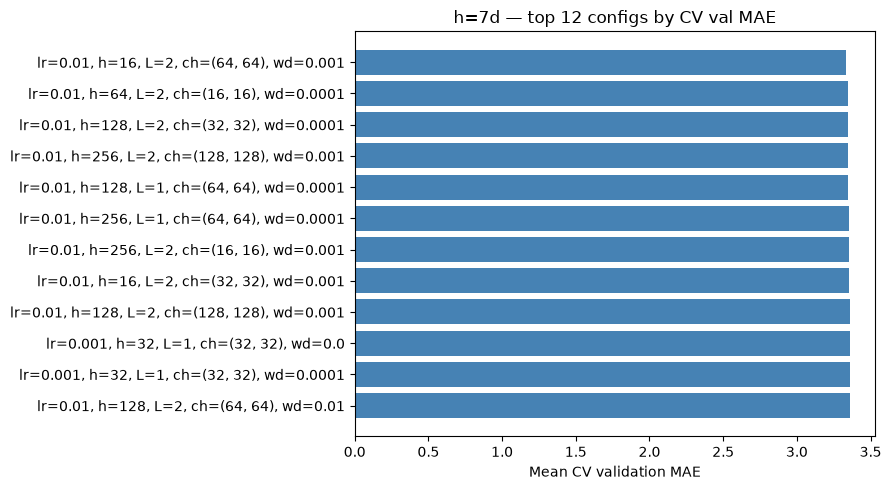

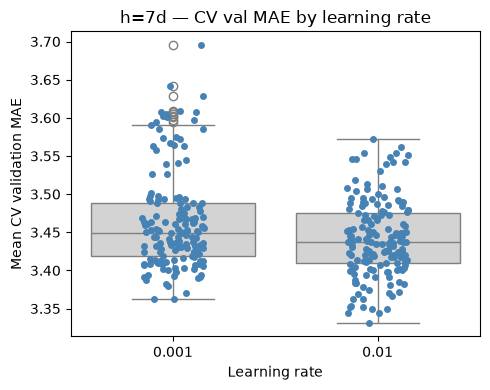

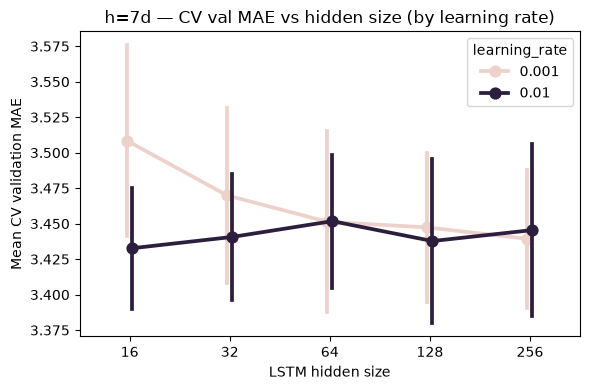

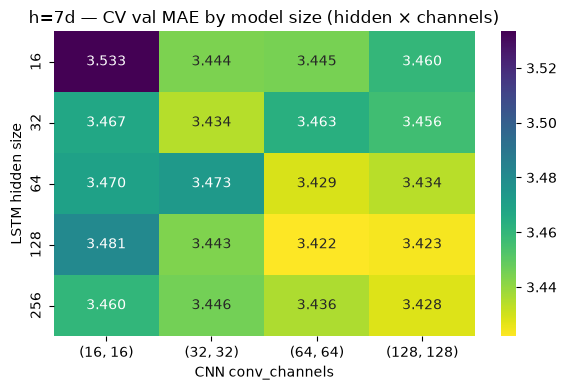

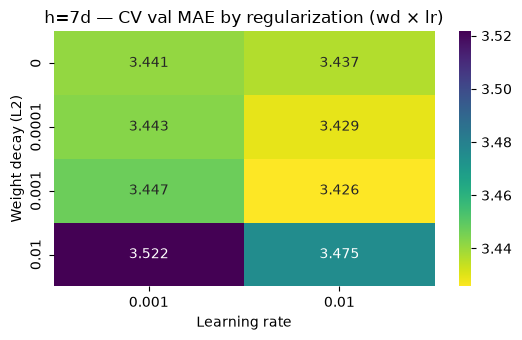

In [ ]:
plot_tuning_results(results_df_7, horizon=7)


#### Final fit (h=7)


Here we retrain the CNN-LSTM model using the best hyperparameters found during the grid search with a fixed time-ordered split of the training sequences, creating a validation set from the last `FINAL_VAL_FRACTION` of the training data. The model is trained on the remaining training data, and early stopping (`EARLY_STOP_PATIENCE`) is applied based on the validation MSE to help with overfitting. The test set is not used during this process to ensure that the model isn't configured around the test set, which would create an over estimation of the model's performance. The best weights from the epoch with the lowest validation MSE are restored for evaluation on the test set.


In [ ]:
torch.manual_seed(42)
model_7 = build_model(
    best_params_7["hidden_size"],
    best_params_7["num_layers"],
    best_params_7["conv_channels"],
    horizon=7,
)

fitX_7, fitY_7, valX_7, valY_7 = time_ordered_train_val_split(
    trainX_7, trainY_7, FINAL_VAL_FRACTION
)

# Final fit: early-stop + restore best epoch by validation MSE (not test)
train_losses_7, val_losses_7, best_epoch_7_final = train_model(
    model_7, #best weights are restored after training to this var
    fitX_7,
    fitY_7,
    valX_7,
    valY_7,
    lr=best_params_7["learning_rate"],
    weight_decay=best_params_7["weight_decay"],
    epochs=NUM_EPOCHS,
    log_every=None,
    restore_best=True,
    patience=EARLY_STOP_PATIENCE,
)
print(
    f"ran {len(train_losses_7)} epochs "
    f"restored best val epoch={best_epoch_7_final}"
)


Early stopping at epoch 36 (no val increase for 20 epochs, best=16)
ran 37 epochs restored best val epoch=16


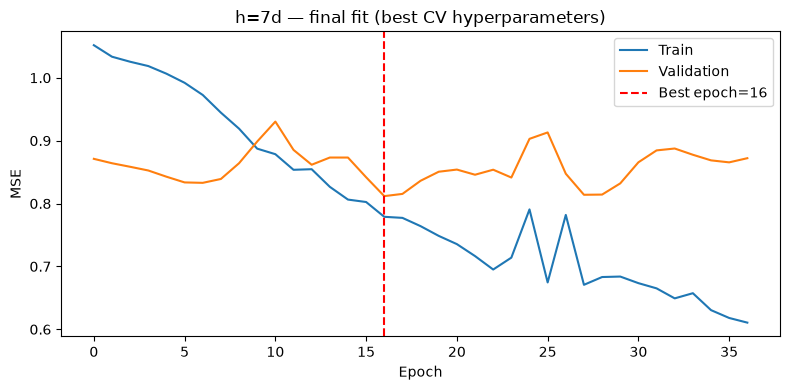

In [ ]:
plot_train_val_loss(
    train_losses_7,
    val_losses_7,
    best_epoch=best_epoch_7_final,
    title="h=7d — final fit (best CV hyperparameters)",
    val_label="Validation",
)


#### Evaluate fit / val (h=7)


In [ ]:
model_7.eval()
with torch.no_grad():
    fit_pred_7 = inverse_target(model_7(fitX_7).numpy())
    val_pred_7 = inverse_target(model_7(valX_7).numpy())

fit_true_7 = inverse_target(fitY_7.numpy())
val_true_7 = inverse_target(valY_7.numpy())

train_mae_7 = mean_absolute_error(fit_true_7.ravel(), fit_pred_7.ravel()) #ravel() flattens the arrays to 1D for MAE calculation
val_mae_7 = mean_absolute_error(val_true_7.ravel(), val_pred_7.ravel())
train_rmse_7 = rmse(fit_true_7.ravel(), fit_pred_7.ravel())
val_rmse_7 = rmse(val_true_7.ravel(), val_pred_7.ravel())

print_metrics("Fit", fit_true_7.ravel(), fit_pred_7.ravel())
print_metrics("Val", val_true_7.ravel(), val_pred_7.ravel())


Fit     MAE: 3.001  RMSE: 4.372
Val     MAE: 3.021  RMSE: 4.494


#### Save best model (h=7)


In [ ]:
save_path_7 = MODEL_DIR / "cnn_lstm_h7.pt"
torch.save(
    {
        "model_state_dict": model_7.state_dict(),
        "horizon": 7,
        "n_features": n_features,
        "best_params": best_params_7,
        "best_epoch": best_epoch_7_final,
        "num_epochs": len(train_losses_7),
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "final_val_fraction": FINAL_VAL_FRACTION,
        "conv_channels": best_params_7["conv_channels"],
        "kernel_size": KERNEL_SIZE,
        "pool_size": POOL_SIZE,
        "dropout": DROPOUT,
        "y_scaler": y_scaler,
        "cv_val_mae": best_7["val_mae"],
        "train_mae": train_mae_7,
        "train_rmse": train_rmse_7,
        "val_mae": val_mae_7,
        "val_rmse": val_rmse_7,
    },
    save_path_7,
)
print(
    f"Saved → {save_path_7}  "
    f"(best val epoch={best_epoch_7_final},did {len(train_losses_7)} epochs)"
)


Saved → saved_cnn_lstm/cnn_lstm_h7.pt  (best val epoch=16,did 37 epochs)


### Forecast horizon: 14 days


In [ ]:
# Sequences for horizon = 14 (scaled targets)
trainX_14, trainY_14 = make_tensors(X_train_scaled, y_train_scaled, 14)
testX_14, testY_14 = make_tensors(X_test_scaled, y_test_scaled, 14)
print("train:", tuple(trainX_14.shape), "test:", tuple(testX_14.shape))


train: (957, 40, 30) test: (321, 40, 30)


#### Grid search (h=14)


Grid search for horizon=14d
  new best [1/320] CV MAE=3.503 ± 0.844  {'learning_rate': 0.001, 'hidden_size': 16, 'num_layers': 1, 'weight_decay': 0.0, 'conv_channels': (128, 128)}
  new best [33/320] CV MAE=3.493 ± 0.822  {'learning_rate': 0.001, 'hidden_size': 32, 'num_layers': 1, 'weight_decay': 0.0, 'conv_channels': (128, 128)}
  new best [35/320] CV MAE=3.484 ± 0.836  {'learning_rate': 0.001, 'hidden_size': 32, 'num_layers': 1, 'weight_decay': 0.0, 'conv_channels': (32, 32)}
  new best [39/320] CV MAE=3.482 ± 0.836  {'learning_rate': 0.001, 'hidden_size': 32, 'num_layers': 1, 'weight_decay': 0.0001, 'conv_channels': (32, 32)}
  [40/320] ...
  new best [43/320] CV MAE=3.482 ± 0.837  {'learning_rate': 0.001, 'hidden_size': 32, 'num_layers': 1, 'weight_decay': 0.001, 'conv_channels': (32, 32)}
  new best [65/320] CV MAE=3.419 ± 0.858  {'learning_rate': 0.001, 'hidden_size': 64, 'num_layers': 1, 'weight_decay': 0.0, 'conv_channels': (128, 128)}
  [80/320] ...
  [120/320] ...
  [160/320

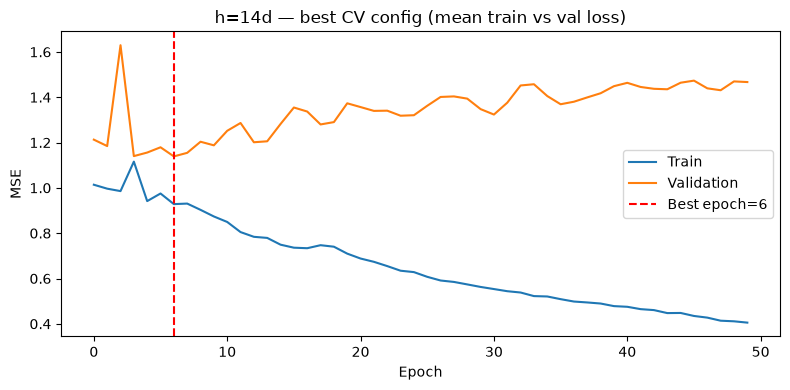

In [ ]:
print("Grid search for horizon=14d")
results_df_14, best_14 = cv_grid_search(trainX_14, trainY_14)

best_params_14 = best_14["params"]
best_epoch_14 = best_14["best_epoch"]  # lowest mean CV val-loss epoch
print("\nBest params (by mean CV MAE):", best_params_14)
print(f"CV MAE = {best_14['val_mae']:.3f}")
print(f"CV best epoch = {best_epoch_14}")
plot_train_val_loss(
    best_14["train_losses"],
    best_14["val_losses"],
    best_epoch=best_epoch_14,
    title="h=14d — best CV config (mean train vs val loss)",
    val_label="Validation",
)


#### Hyperparameter tuning plots (h=14)
Below is a series of hyperparameter tuning plots for each horizon, giving a good overview of the performance of different configurations. 



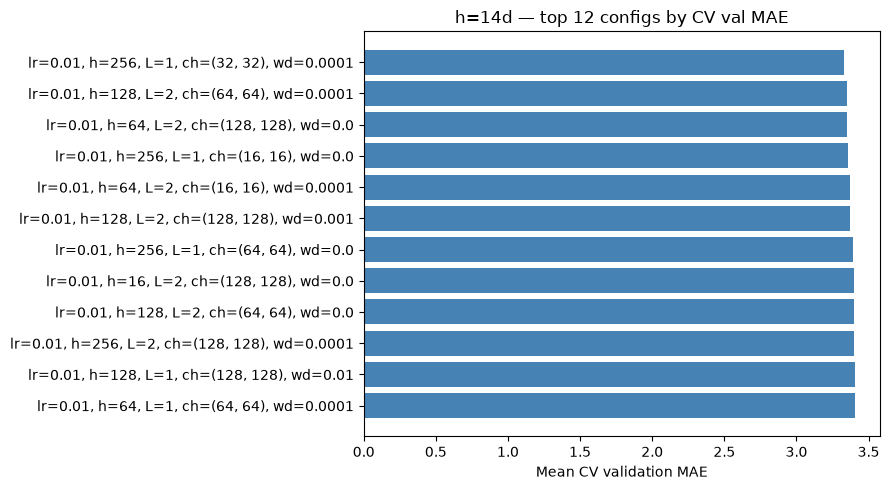

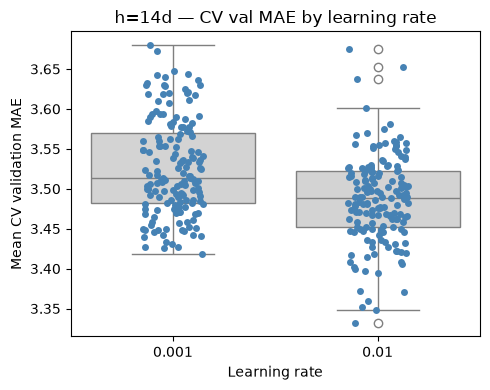

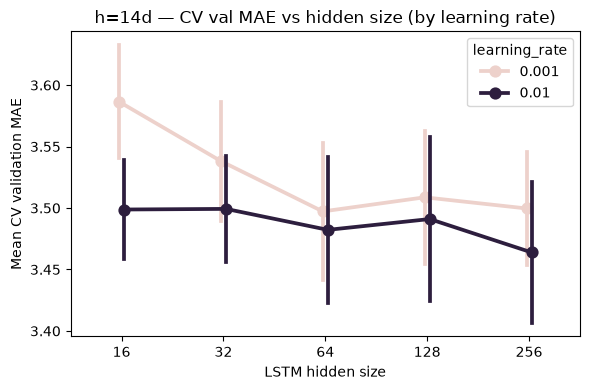

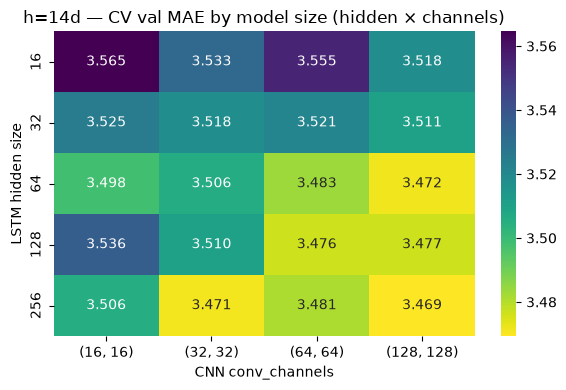

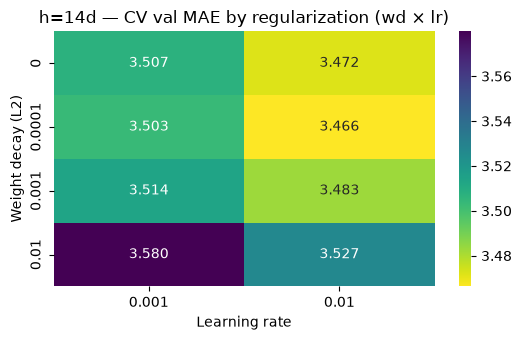

In [ ]:
plot_tuning_results(results_df_14, horizon=14)


#### Final fit (h=14)

Here we retrain the CNN-LSTM model using the best hyperparameters found during the grid search with a fixed time-ordered split of the training sequences, creating a validation set from the last `FINAL_VAL_FRACTION` of the training data. The model is trained on the remaining training data, and early stopping (`EARLY_STOP_PATIENCE`) is applied based on the validation MSE to help with overfitting. The test set is not used during this process to ensure that the model isn't configured around the test set, which would create an over estimation of the model's performance. The best weights from the epoch with the lowest validation MSE are restored for evaluation on the test set.


In [ ]:
torch.manual_seed(42)
model_14 = build_model(
    best_params_14["hidden_size"],
    best_params_14["num_layers"],
    best_params_14["conv_channels"],
    horizon=14,
)

fitX_14, fitY_14, valX_14, valY_14 = time_ordered_train_val_split(
    trainX_14, trainY_14, FINAL_VAL_FRACTION
)

# Final fit: early-stop + restore best epoch by validation MSE (not test)
train_losses_14, val_losses_14, best_epoch_14_final = train_model(
    model_14,
    fitX_14,
    fitY_14,
    valX_14,
    valY_14,
    lr=best_params_14["learning_rate"],
    weight_decay=best_params_14["weight_decay"],
    epochs=NUM_EPOCHS,
    log_every=None,
    restore_best=True,
    patience=EARLY_STOP_PATIENCE,
)
print(
    f"ran {len(train_losses_14)} epochs "
    f"restored best val epoch={best_epoch_14_final}"
)


Early stopping at epoch 30 (no val increase for 20 epochs, best=10)
ran 31 epochs restored best val epoch=10


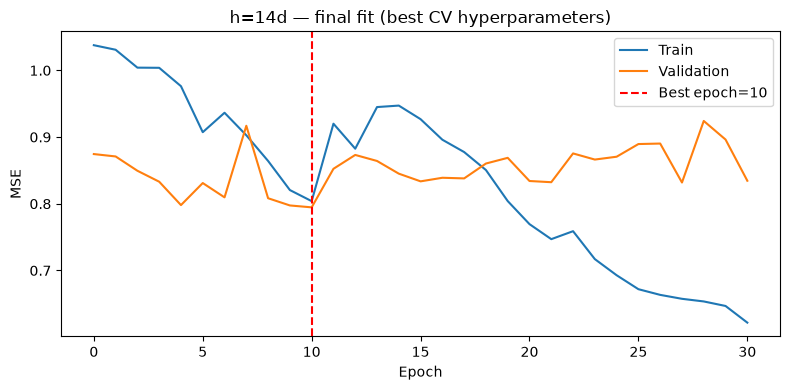

In [ ]:
plot_train_val_loss(
    train_losses_14,
    val_losses_14,
    best_epoch=best_epoch_14_final,
    title="h=14d — final fit (best CV hyperparameters)",
    val_label="Validation",
)


#### Evaluate fit and validation (h=14)


In [ ]:
model_14.eval()
with torch.no_grad():
    fit_pred_14 = inverse_target(model_14(fitX_14).numpy())
    val_pred_14 = inverse_target(model_14(valX_14).numpy())

fit_true_14 = inverse_target(fitY_14.numpy())
val_true_14 = inverse_target(valY_14.numpy())

train_mae_14 = mean_absolute_error(fit_true_14.ravel(), fit_pred_14.ravel())
val_mae_14 = mean_absolute_error(val_true_14.ravel(), val_pred_14.ravel())
train_rmse_14 = rmse(fit_true_14.ravel(), fit_pred_14.ravel())
val_rmse_14 = rmse(val_true_14.ravel(), val_pred_14.ravel())

print_metrics("Fit", fit_true_14.ravel(), fit_pred_14.ravel())
print_metrics("Val", val_true_14.ravel(), val_pred_14.ravel())

Fit     MAE: 3.348  RMSE: 4.733
Val     MAE: 3.066  RMSE: 4.446


#### Save best model (h=14)


In [ ]:
save_path_14 = MODEL_DIR / "cnn_lstm_h14.pt"
torch.save(
    {
        "model_state_dict": model_14.state_dict(),
        "horizon": 14,
        "n_features": n_features,
        "best_params": best_params_14,
        "best_epoch": best_epoch_14_final,
        "num_epochs": len(train_losses_14),
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "final_val_fraction": FINAL_VAL_FRACTION,
        "conv_channels": best_params_14["conv_channels"],
        "kernel_size": KERNEL_SIZE,
        "pool_size": POOL_SIZE,
        "dropout": DROPOUT,
        "y_scaler": y_scaler,
        "cv_val_mae": best_14["val_mae"],
        "train_mae": train_mae_14,
        "train_rmse": train_rmse_14,
        "val_mae": val_mae_14,
        "val_rmse": val_rmse_14,
    },
    save_path_14,
)
print(
    f"Saved → {save_path_14}  "
    f"(best val epoch={best_epoch_14_final}, ran {len(train_losses_14)} epochs)"
)


Saved → saved_cnn_lstm/cnn_lstm_h14.pt  (best val epoch=10, ran 31 epochs)


### Forecast horizon: 30 days


In [ ]:
# Sequences for horizon = 30 (scaled targets)
trainX_30, trainY_30 = make_tensors(X_train_scaled, y_train_scaled, 30)
testX_30, testY_30 = make_tensors(X_test_scaled, y_test_scaled, 30)
print("train:", tuple(trainX_30.shape), "test:", tuple(testX_30.shape))


train: (941, 40, 30) test: (305, 40, 30)


#### Grid search (h=30)


Grid search for horizon=30d
  new best [1/320] CV MAE=3.611 ± 0.833  {'learning_rate': 0.001, 'hidden_size': 16, 'num_layers': 1, 'weight_decay': 0.0, 'conv_channels': (128, 128)}
  new best [2/320] CV MAE=3.577 ± 0.858  {'learning_rate': 0.001, 'hidden_size': 16, 'num_layers': 1, 'weight_decay': 0.0, 'conv_channels': (64, 64)}
  new best [6/320] CV MAE=3.577 ± 0.858  {'learning_rate': 0.001, 'hidden_size': 16, 'num_layers': 1, 'weight_decay': 0.0001, 'conv_channels': (64, 64)}
  new best [10/320] CV MAE=3.564 ± 0.864  {'learning_rate': 0.001, 'hidden_size': 16, 'num_layers': 1, 'weight_decay': 0.001, 'conv_channels': (64, 64)}
  new best [17/320] CV MAE=3.561 ± 0.886  {'learning_rate': 0.001, 'hidden_size': 16, 'num_layers': 2, 'weight_decay': 0.0, 'conv_channels': (128, 128)}
  new best [21/320] CV MAE=3.561 ± 0.886  {'learning_rate': 0.001, 'hidden_size': 16, 'num_layers': 2, 'weight_decay': 0.0001, 'conv_channels': (128, 128)}
  new best [33/320] CV MAE=3.559 ± 0.866  {'learning_ra

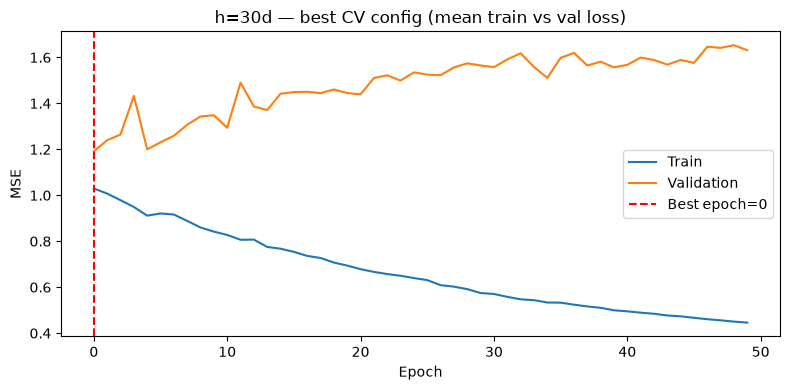

In [ ]:
print("Grid search for horizon=30d")
results_df_30, best_30 = cv_grid_search(trainX_30, trainY_30)

best_params_30 = best_30["params"]
best_epoch_30 = best_30["best_epoch"]  # lowest mean CV val-loss epoch
print("\nBest params (by mean CV MAE):", best_params_30)
print(f"CV MAE = {best_30['val_mae']:.3f}")
print(f"CV best epoch = {best_epoch_30}")
plot_train_val_loss(
    best_30["train_losses"],
    best_30["val_losses"],
    best_epoch=best_epoch_30,
    title="h=30d — best CV config (mean train vs val loss)",
    val_label="Validation",
)


#### Hyperparameter tuning plots (h=30)

Below is a series of hyperparameter tuning plots for each horizon, giving a good overview of the performance of different configurations. 



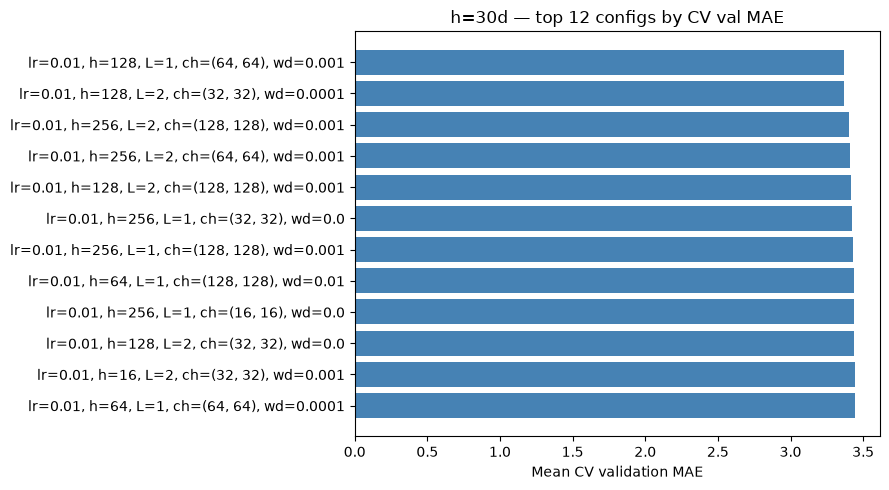

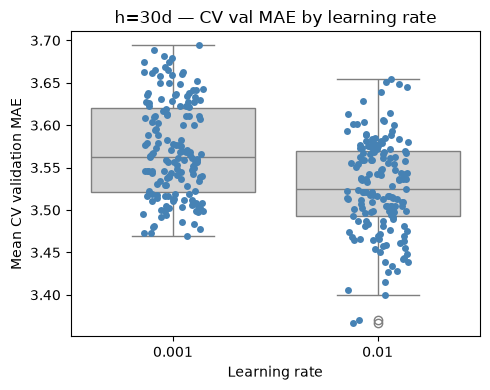

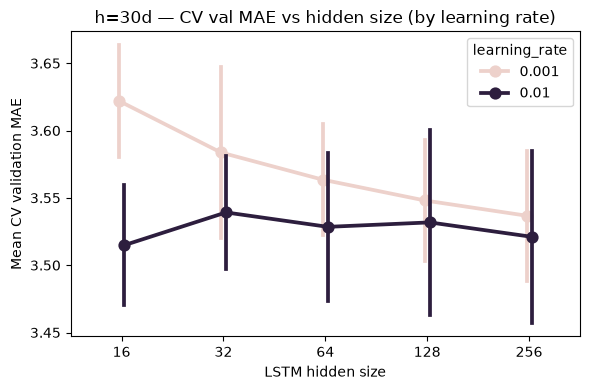

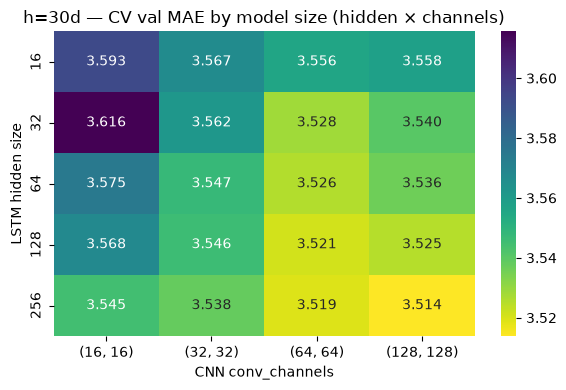

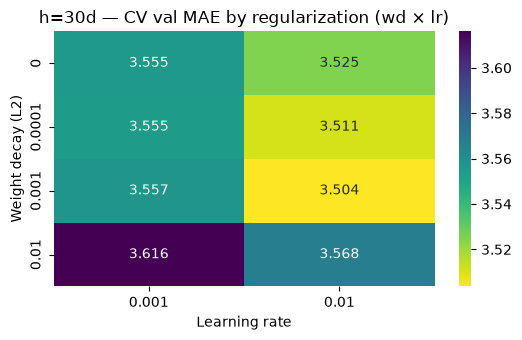

In [ ]:
plot_tuning_results(results_df_30, horizon=30)


#### Final fit (h=30)

Here we retrain the CNN-LSTM model using the best hyperparameters found during the grid search with a fixed time-ordered split of the training sequences, creating a validation set from the last `FINAL_VAL_FRACTION` of the training data. The model is trained on the remaining training data, and early stopping (`EARLY_STOP_PATIENCE`) is applied based on the validation MSE to help with overfitting. The test set is not used during this process to ensure that the model isn't configured around the test set, which would create an over estimation of the model's performance. The best weights from the epoch with the lowest validation MSE are restored for evaluation on the test set.

In [ ]:
torch.manual_seed(42)
model_30 = build_model(
    best_params_30["hidden_size"],
    best_params_30["num_layers"],
    best_params_30["conv_channels"],
    horizon=30,
)

fitX_30, fitY_30, valX_30, valY_30 = time_ordered_train_val_split(
    trainX_30, trainY_30, FINAL_VAL_FRACTION
)

# Final fit: early-stop + restore best epoch by validation MSE
train_losses_30, val_losses_30, best_epoch_30_final = train_model(
    model_30,
    fitX_30,
    fitY_30,
    valX_30,
    valY_30,
    lr=best_params_30["learning_rate"],
    weight_decay=best_params_30["weight_decay"],
    epochs=NUM_EPOCHS,
    log_every=None,
    restore_best=True,
    patience=EARLY_STOP_PATIENCE,
)
print(
    f"ran {len(train_losses_30)} epochs"
    f"restored best val epoch={best_epoch_30_final}"
)


Early stopping at epoch 24 (no val increase for 20 epochs, best=4)
ran 25 epochsrestored best val epoch=4


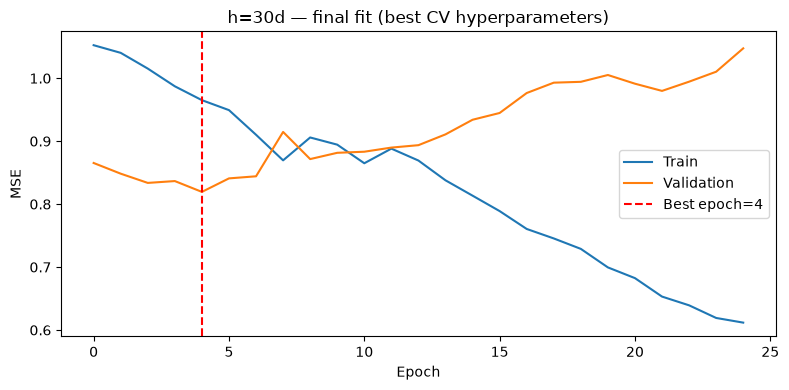

In [ ]:
plot_train_val_loss(
    train_losses_30,
    val_losses_30,
    best_epoch=best_epoch_30_final,
    title="h=30d — final fit (best CV hyperparameters)",
    val_label="Validation",
)


#### Evaluate fit / val (h=30)


In [ ]:
model_30.eval()
with torch.no_grad():
    fit_pred_30 = inverse_target(model_30(fitX_30).numpy())
    val_pred_30 = inverse_target(model_30(valX_30).numpy())

fit_true_30 = inverse_target(fitY_30.numpy())
val_true_30 = inverse_target(valY_30.numpy())

train_mae_30 = mean_absolute_error(fit_true_30.ravel(), fit_pred_30.ravel())
val_mae_30 = mean_absolute_error(val_true_30.ravel(), val_pred_30.ravel())
train_rmse_30 = rmse(fit_true_30.ravel(), fit_pred_30.ravel())
val_rmse_30 = rmse(val_true_30.ravel(), val_pred_30.ravel())

print_metrics("Fit", fit_true_30.ravel(), fit_pred_30.ravel())
print_metrics("Val", val_true_30.ravel(), val_pred_30.ravel())

Fit     MAE: 3.399  RMSE: 4.849
Val     MAE: 3.202  RMSE: 4.515


#### Save best model (h=30)


In [ ]:
save_path_30 = MODEL_DIR / "cnn_lstm_h30.pt"
torch.save(
    {
        "model_state_dict": model_30.state_dict(),
        "horizon": 30,
        "n_features": n_features,
        "best_params": best_params_30,
        "best_epoch": best_epoch_30_final,
        "num_epochs": len(train_losses_30),
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "final_val_fraction": FINAL_VAL_FRACTION,
        "conv_channels": best_params_30["conv_channels"],
        "kernel_size": KERNEL_SIZE,
        "pool_size": POOL_SIZE,
        "dropout": DROPOUT,
        "y_scaler": y_scaler,
        "cv_val_mae": best_30["val_mae"],
        "train_mae": train_mae_30,
        "train_rmse": train_rmse_30,
        "val_mae": val_mae_30,
        "val_rmse": val_rmse_30,
    },
    save_path_30,
)
print(
    f"Saved → {save_path_30}  "
    f"(best val epoch={best_epoch_30_final},did {len(train_losses_30)} epochs)"
)


Saved → saved_cnn_lstm/cnn_lstm_h30.pt  (best val epoch=4,did 25 epochs)


#### Hyperparameter tuning summary:

Across all three forecast horizons (7, 14, and 30 days), we have conducted a comprehensive hyperparameter tuning process using grid search with time-series cross-validation. The best hyperparameters for each horizon have been identified based on mean CV validation MAE, and the final models have been retrained on a time-ordered split of the training sequences with early stopping applied based on validation MSE. The test set has been held out until the final evaluation of the model's performance.

The 7 day model preferred a small LSTM (hidden size of 16, 2 layers), stronger L2 Regularization (weight decay of 0.001), and 64 convolutional channels across both Conv1d layers. The 14 day model in contrast preferred a larger LSTM (hidden size of 256, 1 layer), weaker L2 Regularization (weight decay of 0.0001) and 32 convolutional channels across both Conv1d layers. 30-day model sat in between on capacity (hidden_size=128, 1 layer), kept weight_decay=0.001, and again used (64, 64) channels.

That said, mean CV MAE varied only modestly across the grid. The winning scores were 3.332 ± 0.842 (7-day), 3.332 ± 0.926 (14-day), and 3.367 ± 0.981 (30-day). The drop from the first grid point to the winner was 0.117, 0.171, and 0.244 µg/m³. Those gaps sit well inside the ±0.8 to ±1.0 fold standard deviation, so the ranking is not stable enough to treat as a real architecture effect. Time-series fold is doing more work than hidden size or channel width. The chosen settings are best read as what edged out on mean CV MAE under limited data, not as a clean map of architecture to forecast horizon. This is especially true for the 30-day horizon, where the model failed to learn any meaningful patterns and performance was generally poor across configurations.

## Evaluation


### Load saved models

This is basically just so i can skip retraining the models when I already have saved versions.


In [ ]:
save_path_7 = MODEL_DIR / "cnn_lstm_h7.pt"
save_path_14 = MODEL_DIR / "cnn_lstm_h14.pt"
save_path_30 = MODEL_DIR / "cnn_lstm_h30.pt"

def load_cnn_lstm_checkpoint(path, horizon):
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    bp = ckpt["best_params"]
    model = build_model(
        hidden_size=bp["hidden_size"],
        num_layers=bp["num_layers"],
        conv_channels=bp["conv_channels"],
        horizon=horizon,
    )
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model, bp

model_7, best_params_7 = load_cnn_lstm_checkpoint(save_path_7, 7)
model_14, best_params_14 = load_cnn_lstm_checkpoint(save_path_14, 14)
model_30, best_params_30 = load_cnn_lstm_checkpoint(save_path_30, 30)

print("Loaded CNN-LSTM from:")
print(f"  7-day  {save_path_7.resolve()}")
print(f"  14-day {save_path_14.resolve()}")
print(f"  30-day {save_path_30.resolve()}")
print("best_params_7 ", best_params_7)
print("best_params_14", best_params_14)
print("best_params_30", best_params_30)


Loaded CNN-LSTM from:
  7-day  /Users/matthewbutler/Documents/MastersPaper/code/model_training/saved_cnn_lstm/cnn_lstm_h7.pt
  14-day /Users/matthewbutler/Documents/MastersPaper/code/model_training/saved_cnn_lstm/cnn_lstm_h14.pt
  30-day /Users/matthewbutler/Documents/MastersPaper/code/model_training/saved_cnn_lstm/cnn_lstm_h30.pt
best_params_7  {'learning_rate': 0.01, 'hidden_size': 16, 'num_layers': 2, 'weight_decay': 0.001, 'conv_channels': (64, 64)}
best_params_14 {'learning_rate': 0.01, 'hidden_size': 256, 'num_layers': 1, 'weight_decay': 0.0001, 'conv_channels': (32, 32)}
best_params_30 {'learning_rate': 0.01, 'hidden_size': 128, 'num_layers': 1, 'weight_decay': 0.001, 'conv_channels': (64, 64)}


We will evaluate the performance of our CNN-LSTM model for predicting PM2.5 concentrations at different forecast horizons (7, 14, and 30 days) using the test set. The evaluation will be based on various metrics, including Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R²) to assess the accuracy and reliability of the model's predictions. We will also visualize the predicted vs. actual PM2.5 concentrations to gain insights into the model's performance across different forecast horizons. Furthermore, we will analyze the model's feature importance to gain insights into which features are most influential in predicting PM2.5 concentrations, which can inform future model improvements and provide valuable information for air quality management and policy decisions.

Our model used scaled PM2.5 values for training and validation, but, for this evaluation section, we will only be concerned with inverse-transformed values (µg/m³) for the predictions and true values. All evaluation metrics will be calculated based on the final model weights after early stopping on the validation set, which were restored to the epoch with the lowest validation loss and under the best hyperparameter configuration from cross-validation. We will then evaluate the model's performance on the test set, in order to provide an honest assessment of how well the model generalizes to unseen data. This evaluation will help us determine the effectiveness of our CNN-LSTM model in predicting PM2.5 concentrations and its potential for real-world applications in air quality forecasting.

### Evaluation helpers

Compute MAE, RMSE, R², MAPE, MSE and MBE on the test set for each best model.


In [ ]:
def compute_all_metrics(y_true, y_pred):
    """All of these metrics will be based on the data they are given so, test set metrics will be based on the test set,
      and training metrics will be based on the training set."""
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    r2 = float(r2_score(y_true, y_pred))
    # avoid divide-by-zero on near-zero PM2.5
    mape = float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100) # mean absolute percentage error (MAPE) in percent (abs = absolute value, no negative)
    mbe = float(np.mean(y_pred - y_true))
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape,
        "MSE": mse,
        "MBE": mbe,
    }


def print_all_metrics(name, metrics):
    print(f"{name}")
    print(f"  MAE:  {metrics['MAE']:.3f}")
    print(f"  RMSE: {metrics['RMSE']:.3f}")
    print(f"  R²:   {metrics['R2']:.3f}")
    print(f"  MAPE: {metrics['MAPE']:.2f}%")
    print(f"  MSE:  {metrics['MSE']:.3f}")
    print(f"  MBE:  {metrics['MBE']:.3f}")


def plot_actual_predicted_series(y_true, y_pred, horizon):
    """Line plot of per-origin means (average over lead days) so the x-axis is time-like."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if y_true.ndim == 2:
        # A forecast origin is the final day of the input sequence, and the lead days are the subsequent days for which predictions are made.
        y_true = y_true.mean(axis=1) # average true values over the lead days for each forecast origin (sliding window in the test set)
        y_pred = y_pred.mean(axis=1) # average predicted values over the lead days for each forecast origin (sliding window in the test set)
    plt.figure(figsize=(10, 4))
    plt.plot(y_true, label="Actual (horizon mean)", alpha=0.8)
    plt.plot(y_pred, label="Predicted (horizon mean)", alpha=0.8)
    plt.title(f"h={horizon}d — Actual vs Predicted (test, mean over lead days)")
    plt.xlabel("Forecast origin")
    plt.ylabel("PM2.5 (µg/m³)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_predicted_vs_actual(y_true, y_pred, horizon):
    """Scatter of actual vs predicted over all lead days (pooled), matching test metrics."""
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, alpha=0.5, s=12)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    plt.plot([lo, hi], [lo, hi], "--", color="grey")
    plt.title(f"h={horizon}d — Predicted vs Actual (all lead days)")
    plt.xlabel("Actual PM2.5")
    plt.ylabel("Predicted PM2.5")
    plt.tight_layout()
    plt.show()


def plot_mean_collapse_check(horizon_results, train_mean, test_mean):
    """Overlay actual, predicted, and constant train/test means for each horizon.

    Line plots use the mean over lead days at each forecast origin (readable time series).
    Printed means are still over all origins (same overall level as pooled metrics).
    """
    n = len(horizon_results)
    fig, axes = plt.subplots(n, 1, figsize=(11, 3.2 * n), sharex=False)
    if n == 1:
        axes = [axes]

        # zip keeps the plot axes (subplots) aligned with the corresponding horizon results (actual and predicted values for each horizon)
    for ax, (horizon, y_true, y_pred) in zip(axes, horizon_results): # cycle through each horizon and its corresponding actual and predicted values
        y_true = np.asarray(y_true, dtype=float)
        y_pred = np.asarray(y_pred, dtype=float)
        if y_true.ndim == 2:
            y_true = y_true.mean(axis=1)
            y_pred = y_pred.mean(axis=1)
        ax.plot(y_true, label="Actual (horizon mean)", alpha=0.75, lw=0.9) # plot actual values with some transparency and line width
        ax.plot(y_pred, label="Predicted (horizon mean)", alpha=0.85, lw=0.9) # plot predicted values with some transparency and line width
        ax.axhline( # plot horizontal line for test mean
            test_mean,
            color="C2",
            linestyle="--",
            linewidth=1.6,
            label=f"Test mean ({test_mean:.3f})",
        )
        ax.axhline( # plot horizontal line for train mean
            train_mean,
            color="C3",
            linestyle=":",
            linewidth=1.6,
            label=f"Train mean ({train_mean:.3f})",
        )
        ax.set_ylabel("PM2.5 (µg/m³)")
        ax.set_title(f"h={horizon}d — actual vs predicted vs means (horizon mean per origin)")
        ax.legend(loc="upper right", fontsize=8, ncol=2)
        print(
            f"h={horizon}d: pred mean={y_pred.mean():.3f}, actual mean={y_true.mean():.3f}"
        )

    axes[-1].set_xlabel("Forecast origin")
    fig.suptitle(
        "Mean-collapse check: forecasts vs train/test constant means",
        y=1.01,
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()


### Evaluation for 7-day forecast horizon on test data


In [ ]:
model_7.eval()
with torch.no_grad():
    test_pred_7 = inverse_target(model_7(testX_7).numpy())
test_true_7 = inverse_target(testY_7.numpy())

metrics_7 = compute_all_metrics(test_true_7.ravel(), test_pred_7.ravel())
print_all_metrics("Horizon 7d", metrics_7)

ckpt = torch.load(save_path_7, weights_only=False)
ckpt["test_mae"] = metrics_7["MAE"]
ckpt["test_rmse"] = metrics_7["RMSE"]
torch.save(ckpt, save_path_7)


Horizon 7d
  MAE:  3.827
  RMSE: 6.393
  R²:   0.106
  MAPE: 45.02%
  MSE:  40.866
  MBE:  -1.063


#### Actual vs predicted over time (h=7)

Each point is the **mean of the 7 lead (forecast horizon) days**

for that forecast origin. So the predicted 7 lead day average is plotted against the true 7 lead day average. Scatter and printed metrics still use every lead day.

Previously, when it was every lead day plotted here, the graph was very noisy and hard to interpret. By averaging over the lead days, we can see the overall trend of the model's predictions compared to the true values more clearly.

The blue and orange lines in this graph are based on the average of the lead days for each forecast origin (final day of the input sequence).

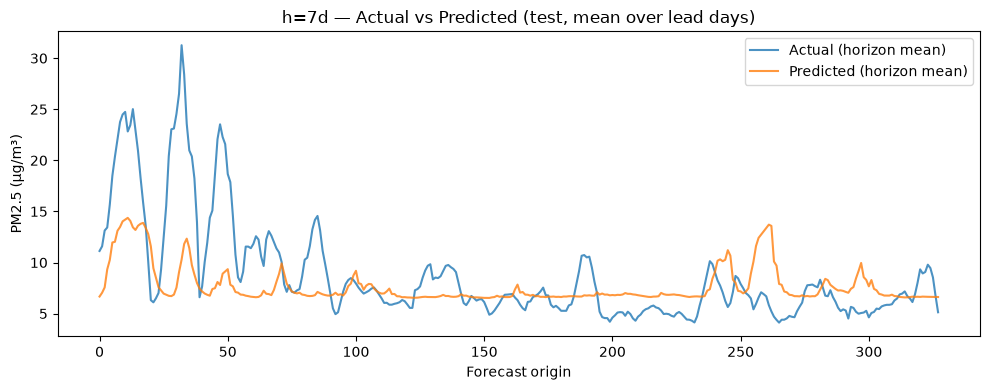

In [ ]:
plot_actual_predicted_series(test_true_7, test_pred_7, horizon=7)


#### Predicted vs actual scatter (h=7)

Each point is one (actual, predicted) pair from any lead day in the 7-day output vector.


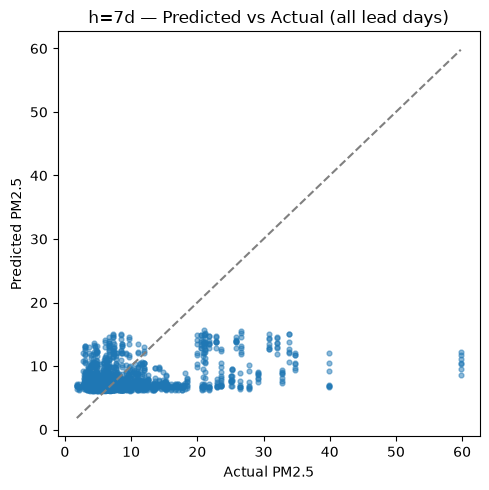

In [ ]:
plot_predicted_vs_actual(test_true_7, test_pred_7, horizon=7)


### Evaluation for 14-day forecast horizon (test set)


In [ ]:
model_14.eval()
with torch.no_grad():
    test_pred_14 = inverse_target(model_14(testX_14).numpy())
test_true_14 = inverse_target(testY_14.numpy())

metrics_14 = compute_all_metrics(test_true_14.ravel(), test_pred_14.ravel())
print_all_metrics("Horizon 14d (test)", metrics_14)

ckpt = torch.load(save_path_14, weights_only=False)
ckpt["test_mae"] = metrics_14["MAE"]
ckpt["test_rmse"] = metrics_14["RMSE"]
torch.save(ckpt, save_path_14)


Horizon 14d (test)
  MAE:  3.912
  RMSE: 6.648
  R²:   0.028
  MAPE: 45.76%
  MSE:  44.198
  MBE:  -1.068


#### Actual vs predicted over time (h=14)

Each point is the **mean of the 14 lead days** for that forecast origin. So the predicted 14 lead day average is plotted against the true 14 lead day average. Scatter and printed metrics still use every lead day.


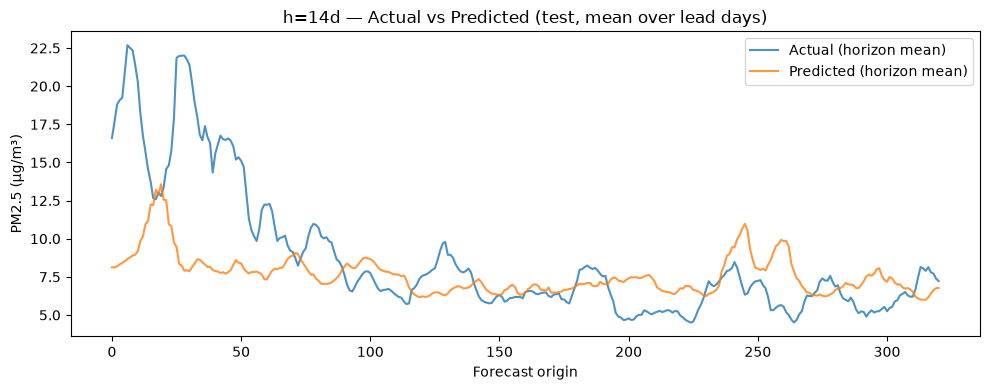

In [ ]:
plot_actual_predicted_series(test_true_14, test_pred_14, horizon=14)


#### Predicted vs actual scatter (h=14)

Each point is one (actual, predicted) pair from any lead day in the 14-day output vector.


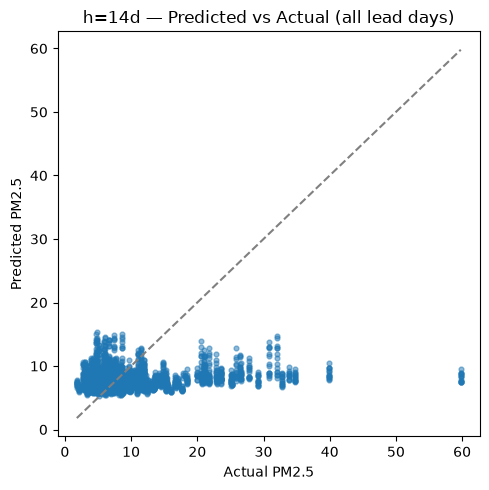

In [ ]:
plot_predicted_vs_actual(test_true_14, test_pred_14, horizon=14)


### Evaluation for 7-day forecast horizon on test data


In [ ]:
model_30.eval()
with torch.no_grad():
    test_pred_30 = inverse_target(model_30(testX_30).numpy())
test_true_30 = inverse_target(testY_30.numpy())

metrics_30 = compute_all_metrics(test_true_30.ravel(), test_pred_30.ravel())
print_all_metrics("Horizon 30d (test)", metrics_30)

ckpt = torch.load(save_path_30, weights_only=False)
ckpt["test_mae"] = metrics_30["MAE"]
ckpt["test_rmse"] = metrics_30["RMSE"]
torch.save(ckpt, save_path_30)


Horizon 30d (test)
  MAE:  4.160
  RMSE: 6.638
  R²:   -0.030
  MAPE: 55.66%
  MSE:  44.061
  MBE:  -0.168


#### Actual vs predicted over time (h=30)

Each point is the **mean of the 30 lead days** for that forecast origin. So the predicted 30 lead day average is plotted against the true 30 lead day average. Scatter and printed metrics still use every lead day.

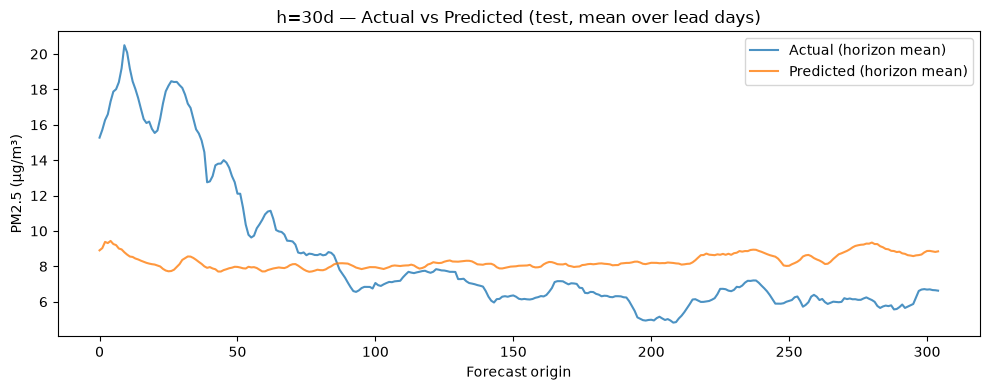

In [ ]:
plot_actual_predicted_series(test_true_30, test_pred_30, horizon=30)


#### Predicted vs actual scatter (h=30)

Each point is one (actual, predicted) pair from any lead day in the 30-day output vector.


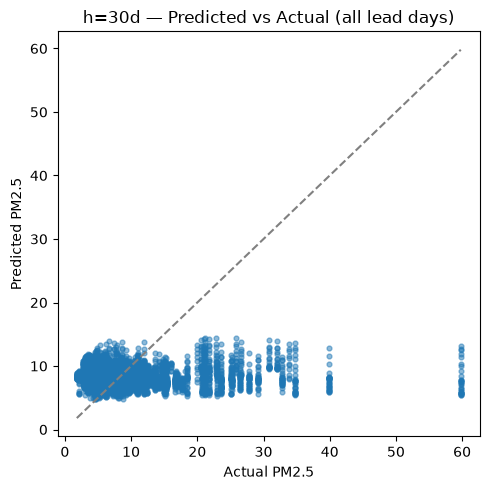

In [ ]:
plot_predicted_vs_actual(test_true_30, test_pred_30, horizon=30)


### Mean-collapse check: predictions vs train/test means

To confirm our theory that the CNN-LSTM is suffering from mean collapse, we will compare the predicted PM2.5 values against the mean of the training and test sets. 

The blue and orange lines in this graph are based on the average of the lead days for each forecast origin (final day of the input sequence).

Train mean PM2.5: 8.490 µg/m³
Test mean PM2.5:  9.196 µg/m³
h=7d: pred mean=7.679, actual mean=8.742
h=14d: pred mean=7.613, actual mean=8.681
h=30d: pred mean=8.286, actual mean=8.454


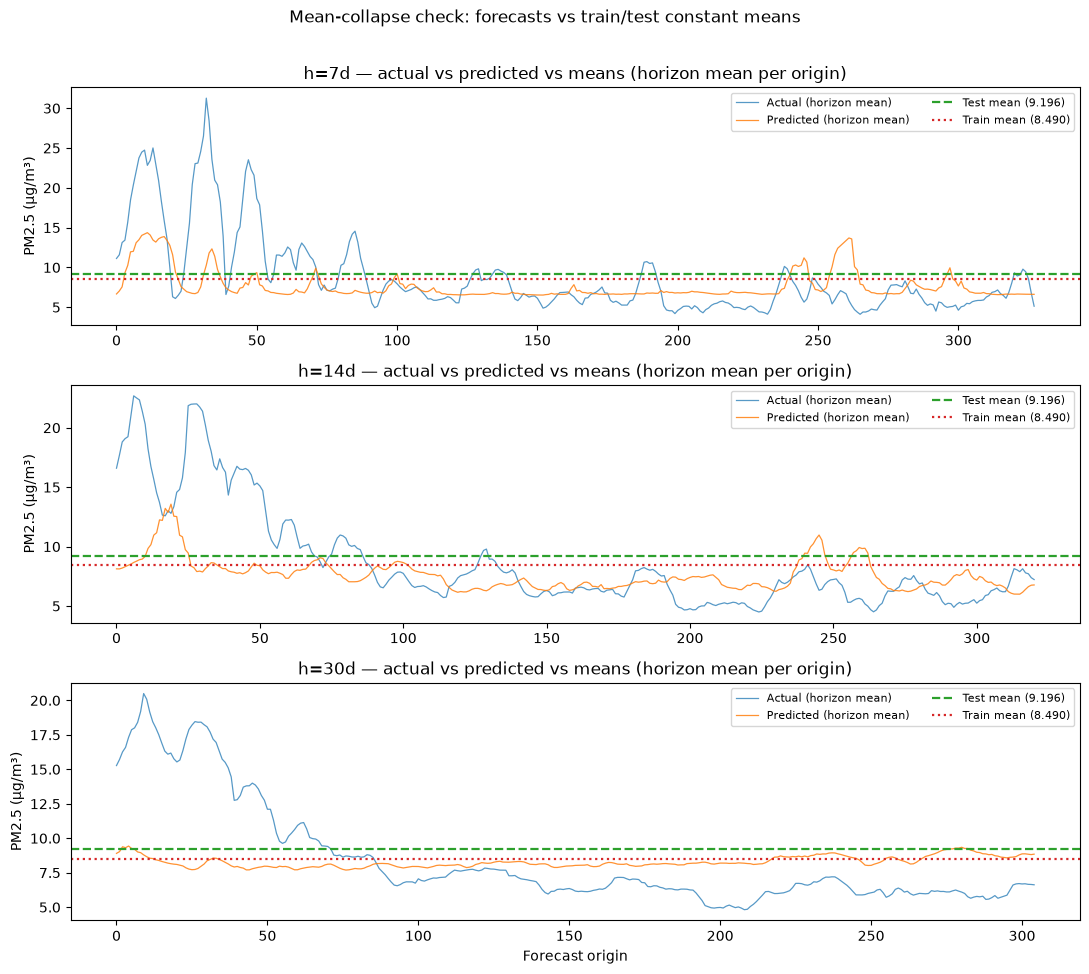

In [ ]:
train_mean_pm25 = float(y_scaler.mean_[0])
test_mean_pm25 = float(y_test.mean())
print(f"Train mean PM2.5: {train_mean_pm25:.3f} µg/m³")
print(f"Test mean PM2.5:  {test_mean_pm25:.3f} µg/m³")

plot_mean_collapse_check(
    [
        (7, test_true_7, test_pred_7),
        (14, test_true_14, test_pred_14),
        (30, test_true_30, test_pred_30),
    ],
    train_mean=train_mean_pm25,
    test_mean=test_mean_pm25,
)


### Different Horizons, the same fate:

The mean-collapse figure above makes the same point visually across horizons. The model does not track peaks and troughs well, predictions flatten toward the **training-set** mean (8.490 µg/m³). The **test-set** mean is higher (9.196 µg/m³), so that collapse also shows up as systematic under-prediction. We expect the model to underpredict PM2.5 concentrations on average, which is consistent with the negative mean bias error (MBE) observed in the evaluation metrics, as its only seen the training set mean during training.

Horizon length (7, 14, 30) does little to change this picture despite the harder multi-step target, this is a partial mean collapse. The 7-day and 14 day models still show a little more movement than 30 days, which sits even closer to a flat near-mean forecast.


### Metrics summary across horizons


In [ ]:
metrics_summary = pd.DataFrame(
    [
        {"horizon": 7, **metrics_7},
        {"horizon": 14, **metrics_14},
        {"horizon": 30, **metrics_30},
    ]
).set_index("horizon")

display(metrics_summary.round(3))


,MAE,RMSE,R2,MAPE,MSE,MBE
horizon,,,,,,
7,3.827,6.393,0.106,45.023,40.866,-1.063
14,3.912,6.648,0.028,45.759,44.198,-1.068
30,4.160,6.638,-0.030,55.659,44.061,-0.168


#### MAE, RMSE, R², MAPE, MSE and MBE for each horizon (7, 14, 30):

The metrics point the same way. There is a weak signal in the forecasts, and it does not last.

Across the 7 day horizon the model still follows some of the peaks and troughs in PM2.5. R² is 0.106, so it accounts for a little over a tenth of the variance. At 14 days that falls to 0.028. At 30 days it is −0.030. R² here is scored against a constant forecast at the test set mean of 9.196 µg/m³. The 7 day model is only marginally better than that baseline, the 14 day model is barely above it, and the 30 day model is slightly worse.

The error metrics move with that. MAE rises from 3.827 at 7 days to 3.912 at 14 days and 4.160 at 30 days. RMSE stays in a tight band, 6.393 then 6.648 then 6.638. MSE does the same, 40.866 then 44.198 then 44.061. Typical absolute and squared errors get worse as we ask the model to look further ahead, which is what daily PM2.5 usually does. MAPE is high at every horizon, 45.023%, 45.759%, and 55.659%. That is a poor summary of skill on this series. Concentrations swing a lot, and the lower values inflate percentage error, so MAE, RMSE, and R² are the more honest read.

MBE is negative at every horizon, −1.063, −1.068, and −0.168, so on average the model underpredicts test set PM2.5. The 7 and 14 day models sit about 1 µg/m³ too low. The 30 day model looks closer to unbiased at −0.168. That is not more skill. R² is negative there and MAE and RMSE are worse. The forecasts have moved toward the training mean of 8.490 µg/m³, which leaves little room for a large systematic bias. It does not mean the 30 day model has found the series.

The CNN-LSTM picks up a modest, real signal at 7 days. That signal fades by 14 days. By 30 days we are slightly worse than predicting the test set mean of 9.196 µg/m³, with forecasts pulled toward the lower training mean of 8.490 µg/m³.


#### Per-lead-day test MSE

Test MSE at each lead day for the three final models (h=7, 14, 30). Lead day 1 is tomorrow, lead day `h` is the last day in that model’s forecast vector.

We calculate the test MSE for each lead day in the forecast horizon, the cost function only outputs a single MSE value for the entire forecast vector, so we need to calculate the MSE for each lead day separately. This allows us to see how the model's performance varies across the forecast horizon and identify any patterns or trends in the errors.

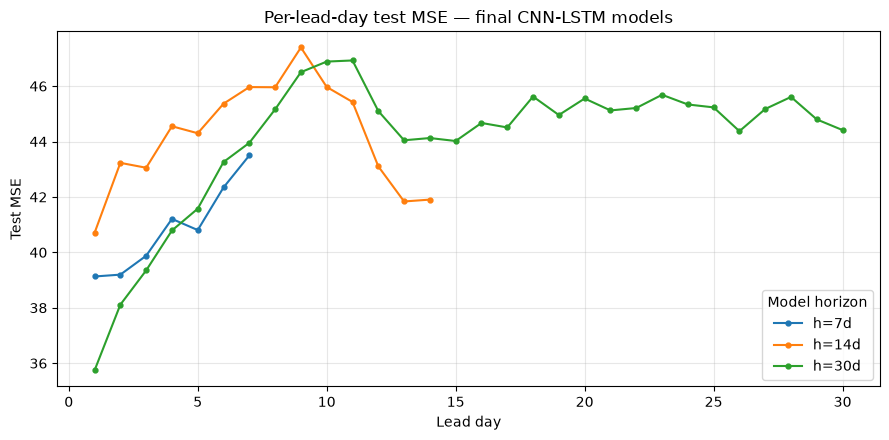

In [ ]:
def per_lead_mse(y_true, y_pred):
    """Mean squared error for each lead day (axis 0 over samples)."""
    err = (np.asarray(y_true, dtype=float) - np.asarray(y_pred, dtype=float)) ** 2
    return err.mean(axis=0)


mse_by_lead = {
    7: per_lead_mse(test_true_7, test_pred_7),
    14: per_lead_mse(test_true_14, test_pred_14),
    30: per_lead_mse(test_true_30, test_pred_30),
}

plt.figure(figsize=(9, 4.5))
for h, mse in mse_by_lead.items():
    days = np.arange(1, len(mse) + 1)
    plt.plot(days, mse, marker="o", markersize=3.5, linewidth=1.5, label=f"h={h}d")
plt.xlabel("Lead day")
plt.ylabel("Test MSE")
plt.title("Per-lead-day test MSE — final CNN-LSTM models")
plt.legend(title="Model horizon")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


This plot shows test MSE for each lead day in the forecast vector, for the three final models (h=7, 14, and 30). Because training uses one overall MSE over the whole horizon, this breakdown is computed afterwards from the predicted vs actual values at each lead day.

In general, error rises as we look further ahead, which is what we would expect for daily PM2.5. The 7-day model (blue) climbs fairly steadily from lead 1 to lead 7. The 14-day and 30-day models both get worse into the first week or so, peak around lead days 9 to 11, then flatten or ease off a bit rather than keeping rising all the way to the end of their horizons.

One slightly surprising detail is that the 30-day model has the lowest MSE on the earliest lead days, even though it was trained for a much longer horizon. Past about a week, though, all three models sit in a similar error band, and the longer horizon models do not improve on the 7-day model overall. This is consistent with the each horizons overall metrics above which state the 7-day model is the only one that shows a modest ability to capture signal, and the longer horizon models are not able to improve on that.

### Metrics vs forecast horizon


In [ ]:
horizons = metrics_summary.index.astype(str)


#### MAE by forecast horizon


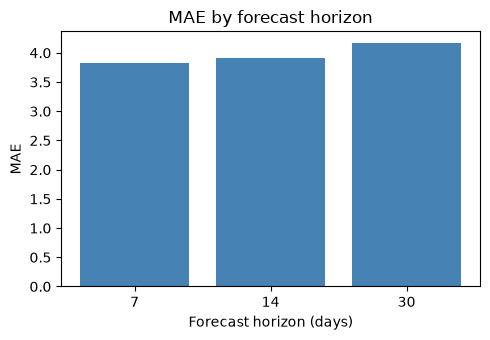

In [ ]:
plt.figure(figsize=(5, 3.5))
plt.bar(horizons, metrics_summary["MAE"], color="steelblue")
plt.title("MAE by forecast horizon")
plt.xlabel("Forecast horizon (days)")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()


For PM2.5, MAE is the average absolute error in µg/m³. If MAE is about 3 µg/m³, then on a typical forecast point we are off by roughly that amount. That matters for public health use, because a few µg/m³ can change how serious a reading looks. Predicting 17 when the truth is 20, or the other way around, is already a different picture. MAE therefore says something practical about how much buffer you might want around warnings.

On our test set, MAE rises with horizon: 3.827 at 7 days, 3.912 at 14 days, and 4.160 at 30 days. Those misses already sit in the few µg/m³ range that can change how a reading looks to a public health user, even at 7 days, and they get worse from there. The rise itself is expected. The target gets harder as we look further ahead. Together with the modest R² values, it still points to only weak skill, strongest at 7 days and fading toward a near mean forecast by 30 days.

#### RMSE by forecast horizon


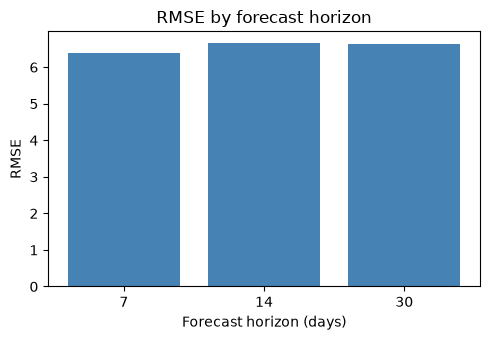

In [ ]:
plt.figure(figsize=(5, 3.5))
plt.bar(horizons, metrics_summary["RMSE"], color="steelblue")
plt.title("RMSE by forecast horizon")
plt.xlabel("Forecast horizon (days)")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()


RMSE is especially useful for air quality because it penalises large mistakes more than MAE. That matters for PM2.5 as short pollution spikes can drive real health risk, so missing a bad day (for example, predicting 10 when it is actually 40) hurts more under RMSE than a small miss on a clean day. In that sense, RMSE pushes attention toward getting the dangerous episodes less wrong.

On the test set, RMSE is 6.393 at 7 days, 6.648 at 14 days, and 6.638 at 30 days. All of these sit high relative to typical levels on the test set (mean 9.196 µg/m³), and they are clearly larger than the corresponding MAEs (~3.8–4.2). That gap is the usual sign that some individual errors are quite big, likely including mis-predicting spikes in PM2.5, not just small day-to-day misses.

Across horizons, RMSE gets worse from 7 to 14 days, then barely changes out to 30 days. So the model’s large-error problem is already serious by two weeks ahead and so stretching the forecast to a month does not make those spike misses much worse in this metric, but it also does not fix them.


#### R² by forecast horizon


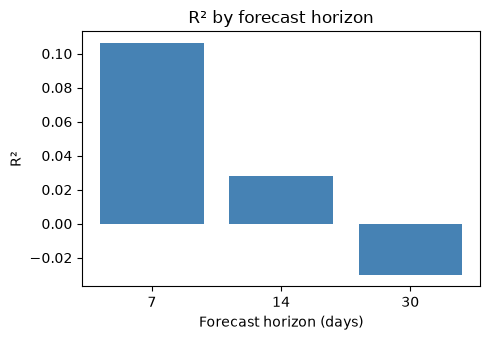

In [ ]:
plt.figure(figsize=(5, 3.5))
plt.bar(horizons, metrics_summary["R2"], color="steelblue")
plt.title("R² by forecast horizon")
plt.xlabel("Forecast horizon (days)")
plt.ylabel("R²")
plt.tight_layout()
plt.show()


R² tells us how much of the variation in PM2.5 our model can actually account for. In PM2.5, concentrations are driven by a messy mix of weather, traffic, industry, and even pollution blowing in from elsewhere, so a high R² would mean the model is picking up those relationships in a useful way. A low R² means a lot of what moves air quality is still outside what the model can see, which is when you start missing odd events or conditions that were rare in training.

On our test set, pooled R² is 0.106 at 7 days, 0.028 at 14 days, and -0.030 at 30 days. The baseline for R² is a constant forecast at the **test-set** mean (9.196 µg/m³). So the 7-day model explains a small but real slice of the variance, the 14-day model is only barely above that baseline, and by 30 days R² goes negative, worse than always predicting 9.196 µg/m³. That drop matches the findings from other metrics, whatever performance the model has at 7 days, it fades away by 30 days. The small negative R² at 30 days is a clear sign that the model is not capturing any meaningful signal at that horizon and is essentially no better than a naive mean forecast.


#### MAPE by forecast horizon


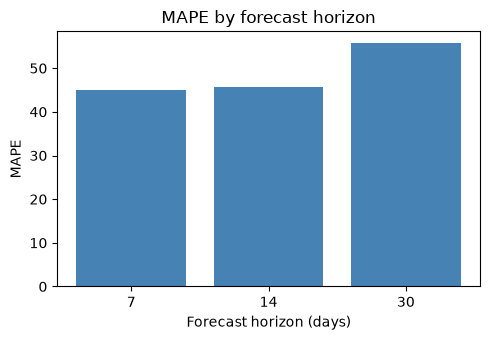

In [ ]:
plt.figure(figsize=(5, 3.5))
plt.bar(horizons, metrics_summary["MAPE"], color="steelblue")
plt.title("MAPE by forecast horizon")
plt.xlabel("Forecast horizon (days)")
plt.ylabel("MAPE")
plt.tight_layout()
plt.show()


Mean Absolute Percentage Error (MAPE) gives a sense of the relative error of the model's predictions compared to the actual values. So it compares each predictions to the corresponding actual value using its scale, then averages those relative errors across all predictions.

On our test set, MAPE is 45.023% at 7 days, 45.759% at 14 days, and 55.659% at 30 days. Relative error is already high at one and two weeks, then jumps clearly by a month. That lines up with the other metrics. Short horizon forecasts are still bad in percentage terms, and by 30 days the model is even less reliable as a proportional guide to pollution levels. We still lean more on MAE, RMSE, and R² for comparing horizons, because MAPE can get inflated on low concentration days, but the chart makes the same point in relative units. Skill gets worse further out.

#### MSE by forecast horizon


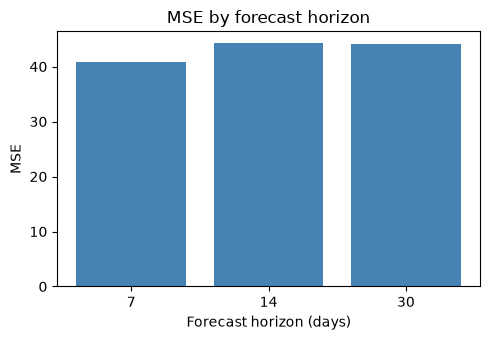

In [ ]:
plt.figure(figsize=(5, 3.5))
plt.bar(horizons, metrics_summary["MSE"], color="steelblue")
plt.title("MSE by forecast horizon")
plt.xlabel("Forecast horizon (days)")
plt.ylabel("MSE")
plt.tight_layout()
plt.show()


MSE is closely tied to how many models learn, since the optimiser minimises MSE during training, in our case on scaled targets. Reporting test MSE keeps the evaluation aligned with that training objective and makes comparison with papers that quote MSE easier, although its units of (µg/m³)² are less intuitive than those of MAE or RMSE.

On our test set, MSE is 40.866 at 7 days, 44.198 at 14 days and 44.061 at 30 days. The error rises between one and two weeks, then barely moves out to a month, which mirrors the plateau seen in RMSE. Most of the increase in squared error has therefore occurred by 14 days, extending the horizon to 30 days does not make the overall cost much worse by this measure, but neither does it recover any of the accuracy seen at 7 days.

#### MBE by forecast horizon


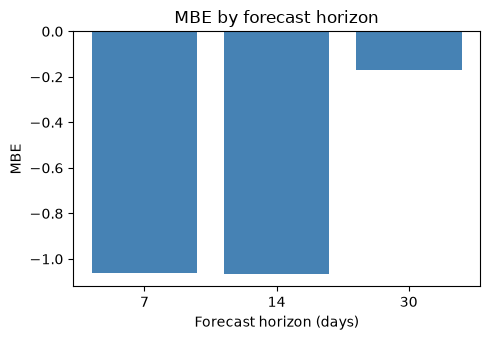

In [ ]:
plt.figure(figsize=(5, 3.5))
plt.bar(horizons, metrics_summary["MBE"], color="steelblue")
plt.title("MBE by forecast horizon")
plt.xlabel("Forecast horizon (days)")
plt.ylabel("MBE")
plt.tight_layout()
plt.show()


Mean bias error matters in air quality because it captures the direction of error, not only its size. A persistently negative MBE means the model systematically underpredicts PM2.5. If forecasts feed advisory warnings, people can then be exposed to higher concentrations than they were told to expect. A persistently positive MBE does the opposite. It generates too many alerts and wears down public confidence in the system. MBE is how we check whether predicted risk is systematically too high or too low relative to what was actually observed.

On the test set, MBE is −1.063 at 7 days, −1.068 at 14 days, and −0.168 at 30 days. All three horizons underpredict on average. The bias is strongest at 7 and 14 days, at about 1 µg/m³ below observed concentrations, and much smaller at 30 days. That smaller figure is not better reliability. It matches a model that has sat down near the series mean, and a near mean forecast has little directional structure left to produce bias either way.

### Feature importance (permutation)

For each feature, shuffle its values across the test set and see how much MAE goes up. A larger increase means the model relied on that feature more. This is simpler than SHAP for a CNN-LSTM.

We are breaking the link between a feature value and its correct target. Randomly moving it to a different row means the model can no longer use that feature to make a correct prediction. If the model relied on that feature, its predictions will get worse and MAE will go up. If the model didn't rely on that feature, MAE won't change much. This is repeated for each feature in turn to get a ranking of which features were most important to the model's predictions.


In [ ]:
def permutation_importance(model, X, y, feature_names, title, top_n=15):
    """Shuffle each feature, MAE increase (µg/m³) = importance."""
    model.eval()
    y_true = inverse_target(y.numpy()).ravel()

    with torch.no_grad():
        base_mae = mean_absolute_error(y_true, inverse_target(model(X).numpy()).ravel())

    scores = {}
    for i, name in enumerate(feature_names): # loop through each feature index and name
        X_shuf = X.clone()  # copy X (samples × features × 30 days) so shuffling one feature does not change the original
        # break the link between this feature and the target
        X_shuf[:, i, :] = X[torch.randperm(len(X)), i, :] # shuffle the values of this feature across all samples, keeping the other features intact

        with torch.no_grad():
            shuf_mae = mean_absolute_error(
                y_true, inverse_target(model(X_shuf).numpy()).ravel() # compute the MAE after shuffling this feature
            )
        scores[name] = shuf_mae - base_mae

    # .items() gives you the tuples of (key, value) pairs in the dictionary,
    #then key = sort by the second element of each tuple (the MAE increase), in ascending order (doesn't do the sorting yet, just specifies the key to sort by)
    # sorted() then performs the sorting based on the specified key, resulting in a list of tuples sorted by MAE increase
    ranked = sorted(scores.items(), key=lambda item: item[1])

    # ranked[-top_n:] takes the last top_n elements from the sorted list (the features with the highest MAE increase)
    # zip * unpacks the tuples into two separate lists: names (feature names) and vals (corresponding MAE increases)
    names, vals = zip(*ranked[-top_n:])

    plt.figure(figsize=(8, 5))
    plt.barh(names, vals, color="teal")
    plt.xlabel("MAE increase when shuffled (µg/m³)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return scores


#### Importance on 7-day model


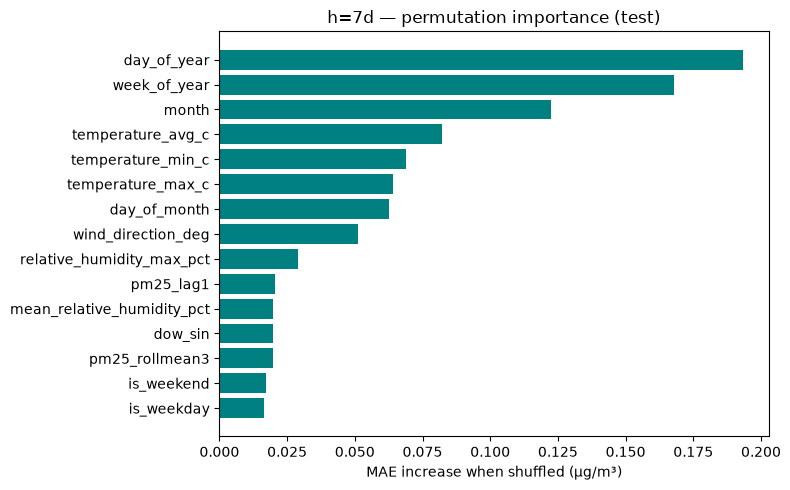

In [ ]:
imp_7 = permutation_importance(
    model_7, testX_7, testY_7, feature_cols,
    title="h=7d — permutation importance (test)",
)


#### Importance on 14-day model


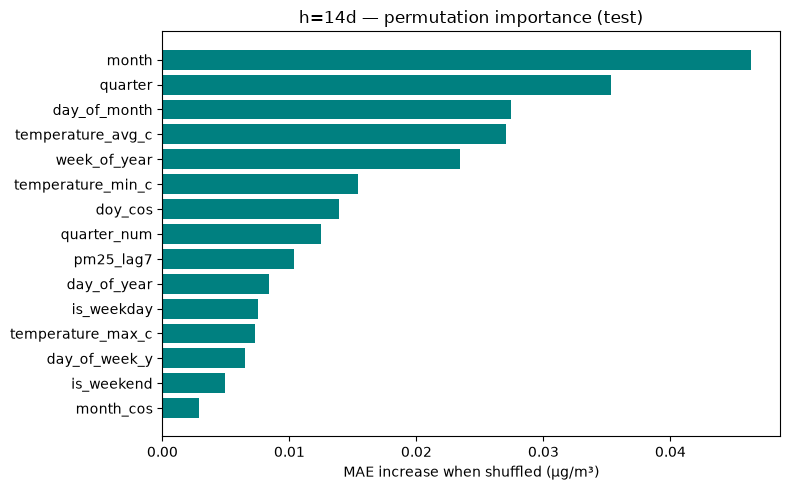

In [ ]:
imp_14 = permutation_importance(
    model_14, testX_14, testY_14, feature_cols,
    title="h=14d — permutation importance (test)",
)


#### Importance on 30-day model


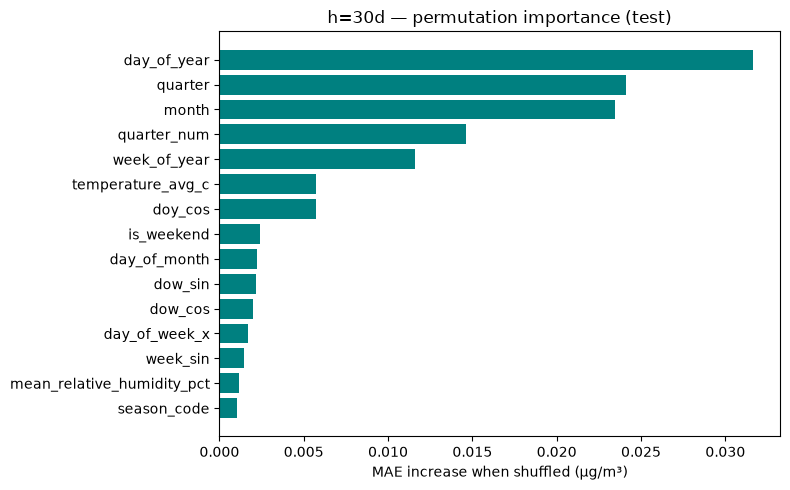

In [ ]:
imp_30 = permutation_importance(
    model_30, testX_30, testY_30, feature_cols,
    title="h=30d — permutation importance (test)",
)


## Save permutation importance

All features, not only the plotted top 15. One file per horizon for the ranking table.


In [ ]:
def permutation_table(scores):
    return (
        pd.DataFrame(
            {"Feature": list(scores.keys()), "Importance_Mean": list(scores.values())}
        )
        .sort_values("Importance_Mean", ascending=False)
        .reset_index(drop=True)
    )


for h, scores in [(7, imp_7), (14, imp_14), (30, imp_30)]:
    path = RESULTS_DIR / f"cnn_lstm_permutation_importance_{h}d.csv"
    permutation_table(scores).to_csv(path, index=False)
    print("Saved", path.resolve())


Saved /Users/matthewbutler/Documents/MastersPaper/code/model_training/cnn_lstm_results/cnn_lstm_permutation_importance_7d.csv
Saved /Users/matthewbutler/Documents/MastersPaper/code/model_training/cnn_lstm_results/cnn_lstm_permutation_importance_14d.csv
Saved /Users/matthewbutler/Documents/MastersPaper/code/model_training/cnn_lstm_results/cnn_lstm_permutation_importance_30d.csv


### Feature importance across horizons


At 7 days, the top features are almost all seasonal (day_of_year, week_of_year, month), with temperature_min_c / avg / max close behind. Weekend and day-of-week flags sit near the bottom, and even pm25_lag1 / pm25_rollmean3 barely move MAE. So for a week-ahead multi-step forecast, the model leans on “where we are in the year” and cold/temperature structure more than other factors.

At 14 days, the same seasonal theme holds (month, quarter, week_of_year, day_of_month), again with temperature in the mix. Absolute importance values are smaller than at 7 days, which fits a weaker overall model. pm25_lag7 (last week’s PM2.5) is now more important than pm25_lag1 (yesterday’s PM2.5), which makes sense for a two-week forecast.

At 30 days, seasonality is even more dominant (day_of_year, quarter, month, week_of_year), and almost everything else is tiny. Even the best feature only lifts MAE by ~0.03 µg/m³. That matches the poor 30-day metrics (negative R² / near-mean behaviour), the model is trying to  use seasonality to get a rough idea of what PM2.5 might be, but it is not capturing any real signal in the data that would allow it to make accurate predictions at that horizon.

However, relative to our MAE baselines for each model, no feature is doing much to improve the forecast. Test MAE is 3.827, 3.912, and 4.160 µg/m³. The 7-day peak is day_of_year at about 0.175 µg/m³. That is the most dominant feature situation and it is still only a small fraction of the 7-day MAE. At 14 days the top bar is about 0.041, at 30 days about 0.03, meaning the model is not really using any feature to get a meaningful improvement in its predictions for 14 or 30 days. This is consistent with the overall evaluation metrics, which show that the model's performance deteriorates as the forecast horizon increases, and it struggles to capture meaningful patterns in the data, especially beyond a week ahead.

#### Analysis Summary:

Grid search with time series cross validation picked a learning rate of 0.01 for all three horizons, and agreed on nothing else. The 7 day model favoured a small, deeper network with hidden_size=16, 2 layers, weight_decay=0.001, channels (64, 64). The 14 day model favoured a wide, shallow one: hidden_size=256, 1 layer, weight_decay=0.0001, channels (32, 32). The 30 day model sat in between: hidden_size=128, 1 layer, weight_decay=0.001, channels (64, 64). These are best read as whatever happened to win on mean CV MAE with the data we have, not as evidence that longer horizons genuinely need different capacity. Each final model was then fitted on a time ordered train/validation split with early stopping on validation MSE. The test set was held back until evaluation.

On the test set the model shows modest skill at 7 days, an R² of roughly 0.11 and MAE of 3.827 µg/m³, but this fades quickly. R² falls to 0.028 at 14 days and to −0.030 at 30. The longer horizons are no better than predicting the test set mean of 9.196 µg/m³, and at 30 days slightly worse. That constant forecast is the R² baseline. MAE rises steadily across the three horizons, 3.827, 3.912, and 4.160. RMSE and MSE worsen and then level off. MAPE stays high throughout. MBE is negative at every horizon. Forecasts are pulled toward the lower training mean of 8.490 µg/m³ while the test mean is 9.196 µg/m³, so the model systematically underpredicts. The prediction plots and permutation importance match that picture. The network relies on seasonality and temperature rather than recent PM2.5 dynamics. It has learned climate, not day to day variation.

With 1,000 training days, a 30 day input window, and multistep targets, the usable sample size is small. The shortest horizon selected one of the smallest LSTMs in the grid. The longer horizons failed to beat a near mean forecast even with more capacity available. That contrast is hard to trust. The model never captured the signal confidently, and the gap between hyperparameter configurations on CV was tiny.

PM2.5 values in this dataset only have modest short term predictability, and a CNN-LSTM of this kind is a poor fit for a dataset this size. It does not capture the available signal reliably beyond about a week. At monthly horizons it converges toward a near mean forecast.


## Next-day horizon sanity check (h=1)

I wanted to validate the model's performance on a next-day forecast horizon (h=1) to ensure that it can accurately predict the target variable for the immediate next day. This serves as a sanity check to confirm that the model is capable of capturing short-term dependencies in the data.

This run uses the same grid search and time-series CV as the 7, 14, and 30-day models, so h=1 gets its own hyperparameters.


In [ ]:
# Sequences for horizon = 1 (scaled targets)
trainX_1, trainY_1 = make_tensors(X_train_scaled, y_train_scaled, 1)
testX_1, testY_1 = make_tensors(X_test_scaled, y_test_scaled, 1)
print("train:", tuple(trainX_1.shape), "test:", tuple(testX_1.shape))


train: (970, 40, 30) test: (334, 40, 30)


#### Grid search (h=1)


Grid search for horizon=1d
  new best [1/320] CV MAE=3.190 ± 0.889  {'learning_rate': 0.001, 'hidden_size': 16, 'num_layers': 1, 'weight_decay': 0.0, 'conv_channels': (128, 128)}
  new best [2/320] CV MAE=3.170 ± 0.810  {'learning_rate': 0.001, 'hidden_size': 16, 'num_layers': 1, 'weight_decay': 0.0, 'conv_channels': (64, 64)}
  new best [6/320] CV MAE=3.169 ± 0.807  {'learning_rate': 0.001, 'hidden_size': 16, 'num_layers': 1, 'weight_decay': 0.0001, 'conv_channels': (64, 64)}
  new best [9/320] CV MAE=3.167 ± 0.872  {'learning_rate': 0.001, 'hidden_size': 16, 'num_layers': 1, 'weight_decay': 0.001, 'conv_channels': (128, 128)}
  new best [10/320] CV MAE=3.159 ± 0.811  {'learning_rate': 0.001, 'hidden_size': 16, 'num_layers': 1, 'weight_decay': 0.001, 'conv_channels': (64, 64)}
  new best [13/320] CV MAE=3.152 ± 0.859  {'learning_rate': 0.001, 'hidden_size': 16, 'num_layers': 1, 'weight_decay': 0.01, 'conv_channels': (128, 128)}
  new best [34/320] CV MAE=3.125 ± 0.868  {'learning_rate

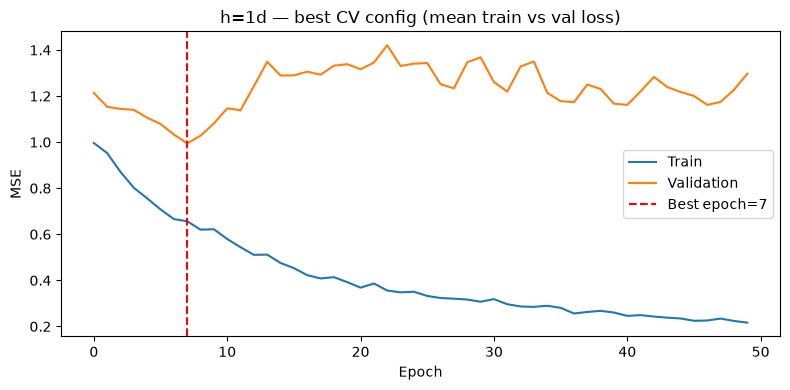

In [ ]:
print("Grid search for horizon=1d")
results_df_1, best_1 = cv_grid_search(trainX_1, trainY_1)

best_params_1 = best_1["params"]
best_epoch_1 = best_1["best_epoch"]  # lowest mean CV val-loss epoch
print("\nBest params (by mean CV MAE):", best_params_1)
print(f"CV MAE = {best_1['val_mae']:.3f}")
print(f"CV best epoch = {best_epoch_1}")
plot_train_val_loss(
    best_1["train_losses"],
    best_1["val_losses"],
    best_epoch=best_epoch_1,
    title="h=1d — best CV config (mean train vs val loss)",
    val_label="Validation",
)


#### Hyperparameter tuning plots (h=1)


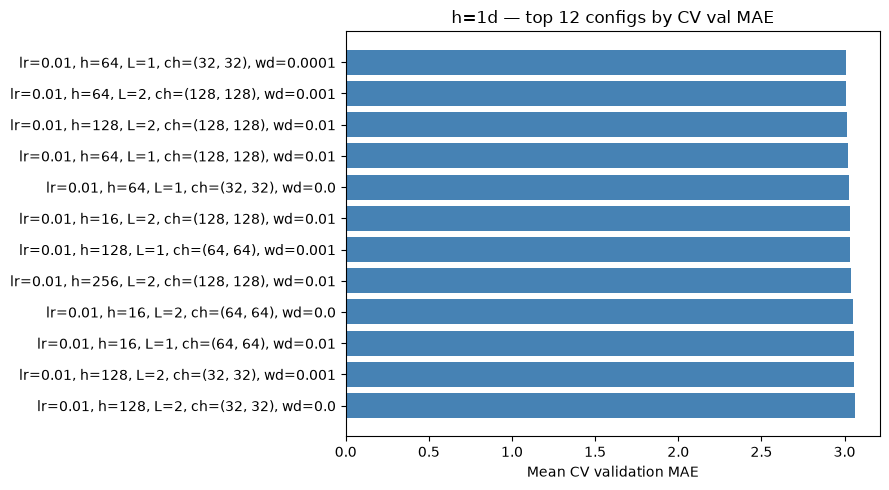

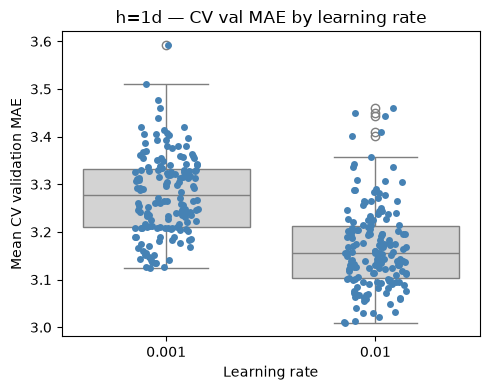

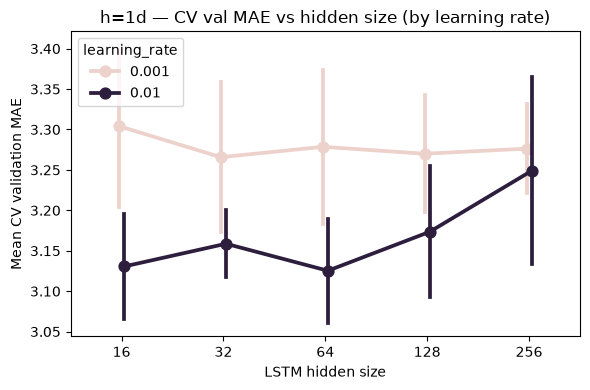

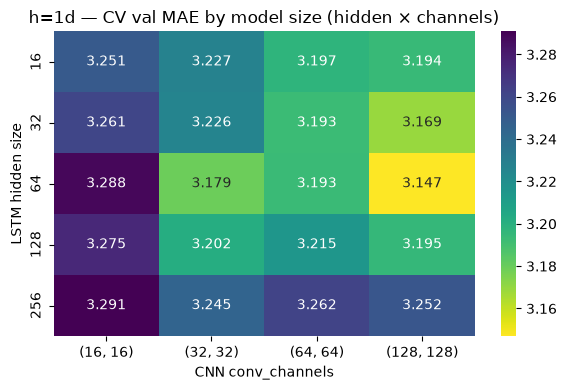

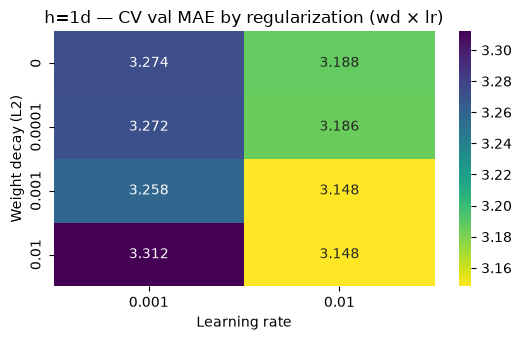

In [ ]:
plot_tuning_results(results_df_1, horizon=1)


#### Final fit (h=1)


In [ ]:
torch.manual_seed(42)
model_1 = build_model(
    best_params_1["hidden_size"],
    best_params_1["num_layers"],
    best_params_1["conv_channels"],
    horizon=1,
)

fitX_1, fitY_1, valX_1, valY_1 = time_ordered_train_val_split(
    trainX_1, trainY_1, FINAL_VAL_FRACTION
)

# Final fit: early-stop + restore best epoch by validation MSE (not test)
train_losses_1, val_losses_1, best_epoch_1_final = train_model(
    model_1,
    fitX_1,
    fitY_1,
    valX_1,
    valY_1,
    lr=best_params_1["learning_rate"],
    weight_decay=best_params_1["weight_decay"],
    epochs=NUM_EPOCHS,
    log_every=None,
    restore_best=True,
    patience=EARLY_STOP_PATIENCE,
)
print(
    f"ran {len(train_losses_1)} epochs "
    f"restored best val epoch={best_epoch_1_final}"
)


Early stopping at epoch 52 (no val increase for 20 epochs, best=32)
ran 53 epochs restored best val epoch=32


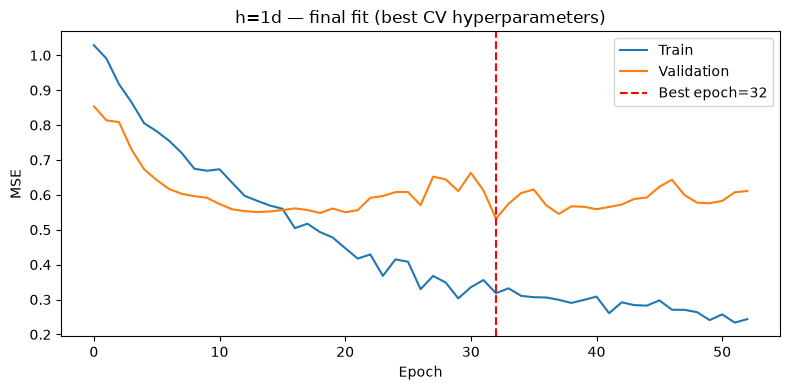

In [ ]:
plot_train_val_loss(
    train_losses_1,
    val_losses_1,
    best_epoch=best_epoch_1_final,
    title="h=1d — final fit (best CV hyperparameters)",
    val_label="Validation",
)


### Evaluation for 1-day forecast horizon on test data


In [ ]:
model_1.eval()
with torch.no_grad():
    test_pred_1 = inverse_target(model_1(testX_1).numpy())
test_true_1 = inverse_target(testY_1.numpy())

metrics_1 = compute_all_metrics(test_true_1.ravel(), test_pred_1.ravel())
print_all_metrics("Horizon 1d", metrics_1)


Horizon 1d
  MAE:  3.166
  RMSE: 4.880
  R²:   0.475
  MAPE: 42.11%
  MSE:  23.813
  MBE:  0.124


## Save test metrics CSV

Lead 1 plus pooled-path 7 / 14 / 30. Same columns as `pooled_path_comparison.ipynb`.


In [ ]:
row_1 = {"Horizon_Days": 1, **metrics_1}
pooled = (
    metrics_summary.reset_index()
    .rename(columns={"horizon": "Horizon_Days"})
)
test_metrics = pd.concat([pd.DataFrame([row_1]), pooled], ignore_index=True)
test_metrics = test_metrics[
    ["Horizon_Days", "MAE", "RMSE", "R2", "MAPE", "MSE", "MBE"]
]
path = RESULTS_DIR / "cnn_lstm_test_metrics.csv"
test_metrics.to_csv(path, index=False)
print("Saved", path.resolve())
display(test_metrics.round(4))


Saved /Users/matthewbutler/Documents/MastersPaper/code/model_training/cnn_lstm_results/cnn_lstm_test_metrics.csv


,Horizon_Days,MAE,RMSE,R2,MAPE,MSE,MBE
0,1,3.1659,4.8798,0.4750,42.1094,23.8128,0.1237
1,7,3.8269,6.3926,0.1063,45.0226,40.8656,-1.0630
2,14,3.9124,6.6481,0.0279,45.7592,44.1976,-1.0676
3,30,4.1601,6.6378,-0.0301,55.6586,44.0607,-0.1677


#### Actual vs predicted over time (h=1)


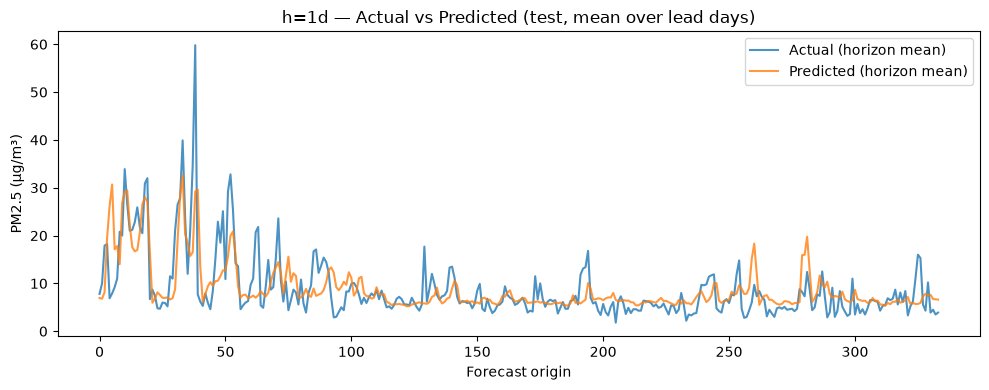

In [ ]:
plot_actual_predicted_series(test_true_1, test_pred_1, horizon=1)


#### Predicted vs actual scatter (h=1)


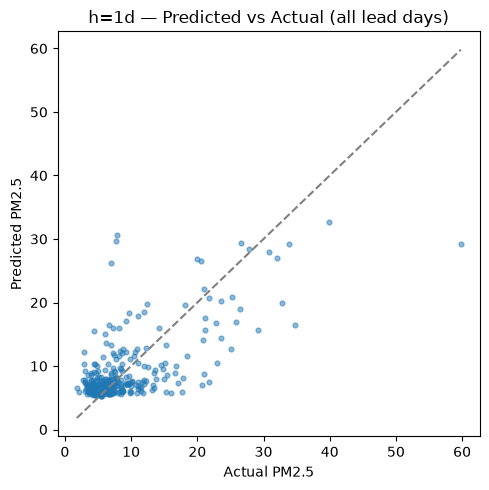

In [ ]:
plot_predicted_vs_actual(test_true_1, test_pred_1, horizon=1)


## Critical Dicussion:

The CNN-LSTM model was able to capture some signal at the 7-day forecast horizon, but its performance deteriorated significantly at longer horizons (14 and 30 days). The model's reliance on time based features such as seasonality (Month, Day of Year, Week of Year) and temperature suggests that it is not effectively capturing the underlying dynamics of PM2.5 concentrations. Instead, it appears to be learning general trends rather than specific day-to-day variations. This limits its ability to make accurate predictions as its understanding of the data is based on broader patterns rather than the immediate factors that influence PM2.5 levels such as recent PM2.5 values, weather conditions, and other relevant features.

The model's performance metrics, including R², MAE, RMSE, and MBE, indicate that it is not able to generalize well to unseen data, particularly at longer forecast horizons. The Mean Collapse check showed that at 30 days, the model's predictions were pulled towards the training set mean, indicating that it was not able to capture any meaningful signal and was essentially making a near-mean forecast. This further support by its small negative R² value at 30 days, which indicates that the model is mariginally worse than a naive mean forecast.

At 7 days, the model was able to capture some signal, as indicated by its R² value of 0.106, however, the other metrics for this horizon (MAE, RMSE, MBE) suggest that the model is still failing to reliably predict PM2.5 concentrations with an MAE of 3.827 µg/m³ tells us the model is on average off by that amount. The RMSE of 6.393 µg/m³ indicates that there are some large errors in the predictions, which could be due to the model's inability to capture short-term spikes in PM2.5 levels. Both of these metrics suggest that the model is not able to provide reliable predictions for public health applications, where accurate forecasts are critical for issuing warnings and taking preventive measures.


When a scatter plot is created to visualize the predicted vs actual PM2.5 concentrations, it shows that the across all horizons, the model's predictions are clustered around the mean of the training set, indicating that it is not able to capture the variability in the data. This further supports the conclusion that the model is not effectively learning the underlying patterns in PM2.5 concentrations and is instead relying on general trends.

The 1 day forecast horizon sanity check showed that the model was able to capture some signal for the immediate next day with an R² value of 0.475, which is a significant improvement over the longer horizons. This suggests that the model is able to capture short-term dependencies in the data, but struggles to generalize to longer forecast horizons. This further supports the conclusion that the CNN-LSTM model is not well-suited for predicting PM2.5 concentrations at longer horizons, and alternative models or approaches may be needed to improve performance.

The limited variance in our hyperparameter tuning results across the grid search suggests that the model is not able to effectively learn from the data under any configuration, and that the model's performance is largely determined by the inherent limitations of the dataset and the model architecture. The small sample size, limited temporal resolution, and lack of strong signal in the data all contribute to the model's inability to capture meaningful patterns in PM2.5 concentrations.

#### Why the CNN-LSTM failed:

The CNN-LSTM model's failure to capture meaningful signal in PM2.5 concentrations can be attributed to several factors:

- The architecture is a poor fit for the sample. Training is about 1,000 days and fewer than four years. Sliding windows overlap by 29 of 30 days, so the effective sample size is much smaller than the number of sequences, Conv filters have no pretrained start, Grid-search CV MAE barely moved across the grid, which is what happens when there is little independent signal to fit.

- The training setup enforces equal weighting of all lead days in the forecast vector. When the model cannot learn meaningful patterns on the later days, those days still count equally in the MSE, so even if the earlier days have some signal, most of the loss comes from the later ones. The value that minimises that average is the training set mean, so the forecasts are pulled toward 8.49 µg/m³. This is a common issue for multi-step models that score the whole horizon with one unweighted MSE when later leads have little usable signal. This finding is further validated by the performance of the 1-day forecast horizon sanity check, which showed that the model was able to capture some signal for the immediate next day, but on our multi-step forecasts, the model struggled to generalize to longer horizons.
